PPT/PDF Attached to this Notebookin Files section(2025em1100234_NLP_Assignment_Sentiment_Analysis_FinalSubmission.pdf) which will get deleted during runtime so needs to be downloaded before run.

Same file is added to notebook as there was no option to upload more than 1 file (which has this .ipynb) on lumen as part of assignment upload

# The Evolution of NLP – Comparing Three Eras of Sentiment Analysis

## Natural Language Processing & Understanding — Graded Assignment

### Comparative Sentiment Analysis Using Traditional ML, Deep Learning & Pretrained NLP

---


**Subject Name:** Natural Language Processing & Understanding

**Course Name:** M.Sc. Data Science & AI

---

### Approaches Compared

| NLP Era | Approach | Model |
|---|---|---|
| Traditional Machine Learning | Statistical / Feature-Based | TF-IDF + Logistic Regression |
| Deep Learning | Sequential Neural Network | PyTorch Embedding + LSTM |
| Pretrained NLP | Off-the-Shelf Inference | VADER |

---

### Dataset

**NLTK Movie Reviews Dataset**

- 2,000 movie reviews
- Positive and negative sentiment categories
- 80% Training / 20% Test split
- Same held-out test set used for all three pipelines

---

### Deliverable

**Jupyter Notebook (.ipynb)**

**MS Powerpoint (.ppt)**

This notebook contains the complete implementation, evaluation,
comparison, and business recommendation for the three sentiment-analysis
approaches.

## Section 1: Project Overview

### 1.1 Project Objective

This project compares three different approaches to sentiment analysis on
the **NLTK Movie Reviews dataset**:

1. **Traditional Machine Learning** — TF-IDF feature representation with
   Logistic Regression.
2. **Deep Learning** — a PyTorch LSTM model using learned word embeddings.
3. **Pretrained NLP Model** — VADER sentiment analysis without
   task-specific training.

The objective is to understand the differences between statistical
machine learning, sequential deep learning, and pretrained NLP approaches
when applied to the same sentiment classification problem.

All three pipelines are evaluated on the **same 20% held-out test set** to
ensure a fair comparison.

### 1.2 Business Context

The project is framed as a technology consulting decision for an
organization that wants to automatically analyze the sentiment expressed
in unstructured movie reviews.

The analysis therefore considers not only predictive performance but also
training requirements, inference time, computational cost, model
complexity, and practical suitability for production deployment.

### 1.3 Project Approach

The overall workflow consists of four major stages:

**Data Sourcing & Preprocessing**
→ **Traditional ML Pipeline**
→ **Deep Learning Pipeline**
→ **Pretrained Model Pipeline**

The outputs of the three approaches are subsequently compared using
Accuracy, Precision, Recall, F1-score, training time, and inference time.

The final section translates the experimental findings into a
business-oriented production recommendation.

## Section 2: Environment Setup

In [ ]:
# ============================================
# 2. Environment Setup
# ============================================

import random
import time
import re

import numpy as np
import pandas as pd

import nltk

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.11.0+cpu


In [ ]:
# ============================================
# Reproducibility
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:
# ============================================
# Hardware Check
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU.")

Selected device: cpu
Running on CPU.


## Section 3: Dataset Sourcing & Initial Inspection



### 3.1 Dataset Source

The assignment requires the NLTK Movie Reviews dataset
(`nltk.corpus.movie_reviews`).

The dataset contains 2,000 movie reviews categorized as positive
or negative.

We will use the NLTK corpus directly rather than downloading a
different movie-review dataset.

### Experimental Principle

All three sentiment-analysis pipelines will be evaluated on
the exact same 20% held-out test set to ensure a fair comparison.



### 3.2 Load Dataset

In [ ]:
# ============================================
# 3.2 Load NLTK Movie Reviews Dataset
# ============================================

nltk.download("movie_reviews")

from nltk.corpus import movie_reviews

print("Categories:", movie_reviews.categories())
print("Total reviews:", len(movie_reviews.fileids()))

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Categories: ['neg', 'pos']
Total reviews: 2000


### 3.3 Dataset Structure

In [ ]:
# ============================================
# 3.3 Create DataFrame
# ============================================

documents = []

for fileid in movie_reviews.fileids():
    review_text = movie_reviews.raw(fileid)
    label = movie_reviews.categories(fileid)[0]

    documents.append({
        "review": review_text,
        "label": label
    })

df = pd.DataFrame(documents)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2000, 2)


,review,label
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


### 3.4 Class Distribution

In [ ]:
# ============================================
# 3.4 Class Distribution
# ============================================

print("Class distribution:")
print(df["label"].value_counts())

print("\nClass proportions:")
print(df["label"].value_counts(normalize=True))

Class distribution:
label
neg    1000
pos    1000
Name: count, dtype: int64

Class proportions:
label
neg    0.5
pos    0.5
Name: proportion, dtype: float64


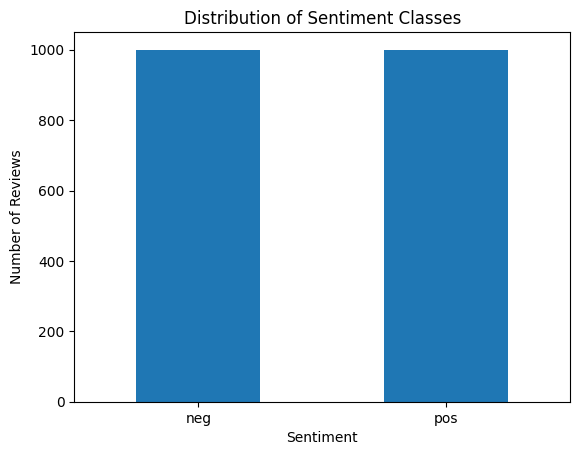

In [ ]:
# ============================================
# Class Distribution Visualization
# ============================================

df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Section 4: Train/Test Split

To ensure a fair comparison between the three NLP approaches, the
dataset is divided into an 80% training set and a 20% test set.

The same held-out test set will be used to evaluate:

1. Traditional Machine Learning
2. Deep Learning with PyTorch LSTM
3. Pretrained Sentiment Model

Stratified sampling is used to preserve the original positive/negative
class distribution in both subsets.

The test set will not be used for model training or vocabulary/
vectorizer fitting.



### 4.1 Create Train/Test Split

In [ ]:
# ============================================
# 4.1 Train/Test Split
# ============================================

X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training samples: 1600
Test samples: 400

Training class distribution:
label
pos    800
neg    800
Name: count, dtype: int64

Test class distribution:
label
neg    200
pos    200
Name: count, dtype: int64


### 4.2 Verify Split

In [ ]:
# ============================================
# 4.2 Verify Split
# ============================================

print("Total samples:", len(X_train) + len(X_test))
print("Training percentage:", len(X_train) / len(df) * 100)
print("Test percentage:", len(X_test) / len(df) * 100)

print("\nTraining positive proportion:",
      (y_train == "pos").mean())

print("Test positive proportion:",
      (y_test == "pos").mean())

Total samples: 2000
Training percentage: 80.0
Test percentage: 20.0

Training positive proportion: 0.5
Test positive proportion: 0.5


## Section 5: Text Preprocessing

### 5.1 Preprocessing Strategy

Text reviews contain linguistic noise that can make machine-learning models
less effective. A consistent preprocessing strategy is therefore applied
before converting the reviews into numerical representations.

The preprocessing strategy includes:

1. Converting text to lowercase.
2. Removing HTML tags and other obvious noise.
3. Removing punctuation and special characters.
4. Removing standalone numeric tokens.
5. Normalizing repeated whitespace.
6. Tokenizing the cleaned text.
7. Removing common stopwords while preserving sentiment-critical negation
   words such as "not", "no", "never", "neither", "nor", and "n't".

### Sentiment-Aware Preprocessing

Stopword removal is performed carefully rather than removing every common
English word. Negation terms can reverse or substantially change sentiment
polarity. For example, "good" and "not good" should not be treated as
equivalent.

Therefore, important negation words are explicitly retained.

### Model-Specific Representation

The cleaned text will be used as the input representation for the
Traditional ML and LSTM pipelines.

The pretrained VADER pipeline will receive the original review text during
inference because VADER is a rule-based pretrained sentiment analyzer whose
polarity scoring can make use of linguistic signals such as punctuation,
capitalization, and emphasis.

This distinction does not change the experimental test set: all three
pipelines will evaluate exactly the same 400 held-out test reviews.

### 5.2 Text Cleaning Function

In [ ]:
# ============================================
# 5.2.1 NLTK Resources for Text Preprocessing
# ============================================

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords

print("NLTK preprocessing resources are ready.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK preprocessing resources are ready.


In [ ]:
# ============================================
# 5.2.2 Sentiment-Aware Stopword Configuration
# ============================================

# Standard English stopwords
standard_stopwords = set(stopwords.words("english"))

# Negation terms that should be preserved because they can change sentiment.
negation_words = {
    "no",
    "not",
    "nor",
    "neither",
    "never",
    "n't"
}

# Remove negation terms from the stopword list so that they are retained.
sentiment_stopwords = standard_stopwords - negation_words

print("Standard stopwords:", len(standard_stopwords))
print("Sentiment-aware stopwords:", len(sentiment_stopwords))
print("Preserved negation words:", sorted(negation_words))

Standard stopwords: 198
Sentiment-aware stopwords: 195
Preserved negation words: ["n't", 'neither', 'never', 'no', 'nor', 'not']


In [ ]:
# ============================================
# 5.2.3 Text Cleaning & Preprocessing Function
# ============================================

# Common contractions relevant to natural-language sentiment analysis
CONTRACTION_MAP = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "wouldn't": "would not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "mustn't": "must not",
    "mightn't": "might not",
    "needn't": "need not",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "he's": "he is",
    "she's": "she is",
    "we're": "we are",
    "they're": "they are",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would"
}


def clean_text(text):
    """
    Clean and preprocess a movie review for NLP modeling.

    Steps:
    1. Convert text to lowercase.
    2. Expand common contractions.
    3. Remove HTML tags.
    4. Remove punctuation and special characters.
    5. Remove standalone numeric tokens.
    6. Tokenize the text.
    7. Remove common stopwords while preserving sentiment-critical
       negation words.
    8. Normalize whitespace.
    """

    # Safety check for missing/non-string values
    if not isinstance(text, str):
        return ""

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Expand common contractions before punctuation removal
    for contraction, expansion in CONTRACTION_MAP.items():
        text = re.sub(
            rf"\b{re.escape(contraction)}\b",
            expansion,
            text
        )

    # 3. Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # 4. Remove tokens containing digits, including dates,
    #    numbers, and alphanumeric forms such as "20th".
    text = re.sub(r"\b\S*\d\S*\b", " ", text)

    # 5. Remove remaining punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 6. Tokenize
    tokens = nltk.word_tokenize(text)

    # 7. Remove stopwords while preserving sentiment-critical
    #    negation words such as not, no, never, nor, neither
    tokens = [
        token
        for token in tokens
        if token not in sentiment_stopwords
    ]

    # 8. Normalize whitespace
    cleaned_text = " ".join(tokens)

    return cleaned_text.strip()

In [ ]:
# ============================================
# 5.2.4 Test the Preprocessing Function
# ============================================

sample_reviews = [
    "This movie was absolutely fantastic! I loved it.",
    "This movie was NOT good. I never enjoyed it.",
    "<br />A terrible movie!!! 12345",
    "The acting was good, but the story was not convincing."
]

for i, review in enumerate(sample_reviews, start=1):
    print(f"\nExample {i}")
    print("Original :", review)
    print("Cleaned  :", clean_text(review))


Example 1
Original : This movie was absolutely fantastic! I loved it.
Cleaned  : movie absolutely fantastic loved

Example 2
Original : This movie was NOT good. I never enjoyed it.
Cleaned  : movie not good never enjoyed

Example 3
Original : <br />A terrible movie!!! 12345
Cleaned  : terrible movie

Example 4
Original : The acting was good, but the story was not convincing.
Cleaned  : acting good story not convincing


### 5.3 Before/After Examples

In [ ]:
for i in range(3):
    original = X_train.iloc[i]
    cleaned = clean_text(original)

    print(f"\nExample {i + 1}")
    print("-" * 80)
    print("Original:")
    print(original[:500])

    print("\nCleaned:")
    print(cleaned[:500])


Example 1
--------------------------------------------------------------------------------
Original:
saving private ryan ( dreamworks ) running time : 2 hours 48 minutes . 
starring tom hanks , edward burns , tom sizemore and matt damon directed by steven spielberg already being hailed as the 'greatest war movie ever made , ' saving private ryan is an harrowing , saddening and riveting movie . 
it may not be the greatest war movie in my opinion , but it's certainly one of the best war movies made , and one of the best of 1998 . 
tom hanks stars as a captain who's troop has to find private ryan 

Cleaned:
saving private ryan dreamworks running time hours minutes starring tom hanks edward burns tom sizemore matt damon directed steven spielberg already hailed greatest war movie ever made saving private ryan harrowing saddening riveting movie may not greatest war movie opinion certainly one best war movies made one best tom hanks stars captain troop find private ryan damon ticket home thr

####  Before/After Examples Observations

The preprocessing function was validated using both controlled examples and
actual movie reviews from the training dataset. The before-and-after examples
confirm that the cleaning process reduces textual noise while retaining
important sentiment-bearing words.

#### Controlled Examples

The controlled examples demonstrate the main preprocessing behaviors:

- Common words such as "this", "was", "it", and "the" are removed as
  stopwords.
- Punctuation and special characters are removed.
- HTML markup such as `<br />` is removed.
- Standalone numeric content such as `12345` is removed.
- Sentiment-bearing words such as "fantastic", "terrible", "good", and
  "convincing" are retained.
- Negation terms such as "not" and "never" are preserved.

For example, the review:

> "This movie was NOT good. I never enjoyed it."

is transformed into:

> "movie not good never enjoyed"

This demonstrates that sentiment-critical negation information is retained
during preprocessing.

#### Examples from the Training Dataset

The same preprocessing function was then applied to actual movie reviews
from the training data.

The examples show that the preprocessing removes punctuation, formatting
symbols, and common stopwords while retaining meaningful content such as
movie titles, names, descriptive words, and sentiment-related terms.

For example, the review discussing *Saving Private Ryan* retains meaningful
terms such as "harrowing", "saddening", "riveting", "best", and "not", while
removing punctuation, numeric information, and common stopwords.

Similarly, the review discussing *The Sixth Sense* retains descriptive and
sentiment-relevant terms such as "suspenseful", "unexpected", "spooky",
"scary", and "not".

The *Dark City* example also demonstrates preservation of negation after
contraction handling. For example, "doesn't have any way" is represented as
"not way", ensuring that the negative sentiment signal is not completely
discarded.

Overall, the examples confirm that the preprocessing function reduces
textual noise while preserving important words and negation information
required for downstream sentiment classification.

### 5.4 Apply Preprocessing

In [ ]:
# ============================================
# 5.4 Apply Preprocessing to Train and Test Sets
# ============================================

# Apply the same preprocessing function to the training and test text.
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

print("Training reviews after preprocessing:", len(X_train_clean))
print("Test reviews after preprocessing:", len(X_test_clean))

print("\nExample cleaned training review:")
print(X_train_clean.iloc[0])

Training reviews after preprocessing: 1600
Test reviews after preprocessing: 400

Example cleaned training review:
saving private ryan dreamworks running time hours minutes starring tom hanks edward burns tom sizemore matt damon directed steven spielberg already hailed greatest war movie ever made saving private ryan harrowing saddening riveting movie may not greatest war movie opinion certainly one best war movies made one best tom hanks stars captain troop find private ryan damon ticket home three brothers killed action action drama even humour occur troop journeys wartime france find disappointing amistad spielberg returned form excellent movie not war movie genre biggest fan found film gripping scary thanks excellent cast direction terrifying battle scenes tom hanks superb straying away usually soppy dramatic roles forrest gump time plays role gritty realism much better occasionally overacts sentimentally generally delivers fine performance edward burns looking lot like armageddon 

In [ ]:
# ============================================
# 5.4.1 Verify Text-Label Alignment
# ============================================

print("Training text samples:", len(X_train_clean))
print("Training labels:", len(y_train))

print("Test text samples:", len(X_test_clean))
print("Test labels:", len(y_test))

print("\nTraining alignment:", len(X_train_clean) == len(y_train))
print("Test alignment:", len(X_test_clean) == len(y_test))

Training text samples: 1600
Training labels: 1600
Test text samples: 400
Test labels: 400

Training alignment: True
Test alignment: True


In [ ]:
# ============================================
# 5.4.2 Verify Class Distribution After Cleaning
# ============================================

print("Training class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))

Training class distribution:
label
pos    800
neg    800
Name: count, dtype: int64

Test class distribution:
label
neg    200
pos    200
Name: count, dtype: int64

Training class proportions:
label
pos    0.5
neg    0.5
Name: proportion, dtype: float64

Test class proportions:
label
neg    0.5
pos    0.5
Name: proportion, dtype: float64


In [ ]:
# ============================================
# 5.4.3 Preserve Original Test Reviews
# ============================================

print("Original test reviews available:", len(X_test))
print("Cleaned test reviews available:", len(X_test_clean))

print("\nOriginal test example:")
print(X_test.iloc[0][:300])

print("\nCleaned test example:")
print(X_test_clean.iloc[0][:300])

Original test reviews available: 400
Cleaned test reviews available: 400

Original test example:
dr dolittle ( 20th century fox ) running time : 1 hour 25 minutes starring eddie murphy directed by betty thomas riding high on the success of the nutty professor ( 1996 ) , murphy returns in this abysmal comedy . 
he plays doctor john dolittle , who as a child had the ability to understand animals 

Cleaned test example:
dr dolittle century fox running time hour minutes starring eddie murphy directed betty thomas riding high success nutty professor murphy returns abysmal comedy plays doctor john dolittle child ability understand animals however exorcised loses ability fast forward see dolittle crummy job surrounding


#### Apply Preprocessing Observations

The finalized text-cleaning function was applied to both the training and
held-out test reviews.

After preprocessing, the dataset retained all 1,600 training reviews and
400 test reviews. The corresponding training and test labels remained fully
aligned with their cleaned text samples, with both alignment checks returning
`True`.

The class distribution was also unchanged. The training set contains 800
positive and 800 negative reviews, while the test set contains 200 positive
and 200 negative reviews. Therefore, both datasets maintain an equal 50%
positive and 50% negative class proportion after preprocessing.

The original test reviews were retained separately from their cleaned
versions. This is intentional because the cleaned representation will be
used by the Traditional ML and LSTM pipelines, while the original test
reviews will be retained for the pretrained VADER pipeline.

This preserves a common held-out test set of 400 reviews for all three
approaches while allowing each model to use an appropriate input
representation.

### 5.5 Preprocessing Quality Check

In [ ]:
# ============================================
# 5.5 Preprocessing Quality Check
# ============================================

empty_train = (X_train_clean.str.strip().str.len() == 0).sum()
empty_test = (X_test_clean.str.strip().str.len() == 0).sum()

print("Empty training reviews:", empty_train)
print("Empty test reviews:", empty_test)

Empty training reviews: 0
Empty test reviews: 0


In [ ]:
# ============================================
# 5.5.1 Cleaned Review Length Check
# ============================================

train_word_counts = X_train_clean.str.split().str.len()
test_word_counts = X_test_clean.str.split().str.len()

print("Training review word-count statistics:")
print(train_word_counts.describe())

print("\nTest review word-count statistics:")
print(test_word_counts.describe())

Training review word-count statistics:
count    1600.000000
mean      358.664375
std       153.435253
min         7.000000
25%       256.000000
50%       335.000000
75%       431.250000
max      1401.000000
Name: review, dtype: float64

Test review word-count statistics:
count     400.000000
mean      356.822500
std       160.633336
min        31.000000
25%       247.000000
50%       334.000000
75%       434.000000
max      1218.000000
Name: review, dtype: float64


In [ ]:
# ============================================
# 5.5.2 Check Very Short Cleaned Reviews
# ============================================

short_train = (train_word_counts <= 3).sum()
short_test = (test_word_counts <= 3).sum()

print("Training reviews with 3 or fewer words:", short_train)
print("Test reviews with 3 or fewer words:", short_test)

Training reviews with 3 or fewer words: 0
Test reviews with 3 or fewer words: 0


#### Preprocessing Quality Check Observations

A quality check was performed after preprocessing to ensure that the
cleaning process did not remove excessive information or produce unusable
reviews.

No empty reviews were produced in either dataset. The training and test
sets contained zero reviews with three or fewer words after preprocessing.
This indicates that the cleaning process retained sufficient textual
content across all observations.

The cleaned training reviews contained an average of 358.66 words, with a
median of 335 words and a maximum of 1,401 words. The cleaned test reviews
had a similar average of 356.82 words, a median of 334 words, and a maximum
of 1,218 words.

The similarity between the training and test review-length distributions
provides an additional data-quality check and does not indicate an obvious
distributional difference introduced by preprocessing.

The wide range of review lengths will also be considered when selecting an
appropriate sequence length for the LSTM pipeline.

### 5.6 Review Length Analysis

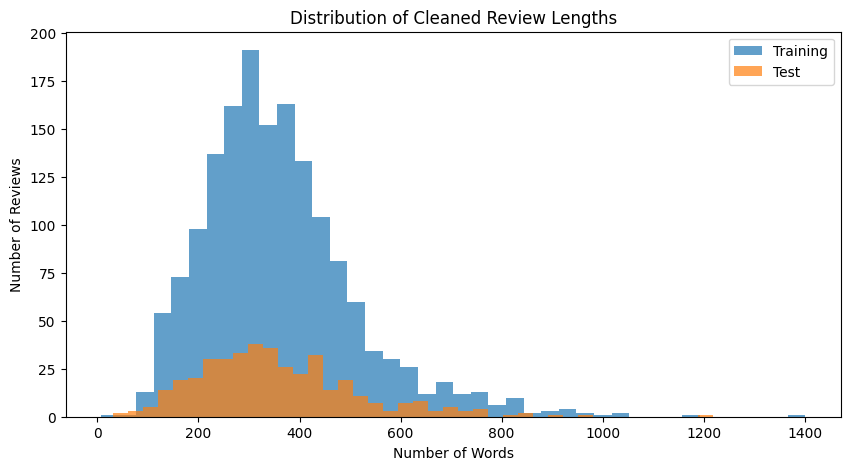

In [ ]:
# ============================================
# 5.6 Review Length Analysis
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(train_word_counts, bins=40, alpha=0.7, label="Training")
plt.hist(test_word_counts, bins=40, alpha=0.7, label="Test")

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Cleaned Review Lengths")
plt.legend()
plt.show()

#### Review Length Analysis Observations

The distribution of cleaned review lengths was examined to understand the
amount of textual information available for downstream modeling.

The histogram shows that most reviews in both the training and test sets are
concentrated approximately between 200 and 500 words. The training and test
distributions have a broadly similar shape and substantial overlap, which
provides a visual indication that the preprocessing has not introduced an
obvious difference in review length between the two sets.

The distribution is right-skewed, with a smaller number of substantially
longer reviews extending beyond 1,000 words. The maximum cleaned review
length is 1,401 words in the training set and 1,218 words in the test set.

This variation in review length is particularly relevant for the LSTM
pipeline because neural sequence models require a fixed sequence length.
Rather than using the maximum review length, which would introduce
substantial padding for many reviews, the sequence length will be selected
later based on the observed distribution and practical modeling
considerations.

## Section 6: TF-IDF

### 6.1 TF-IDF Feature Representation

For the traditional machine learning pipeline, the cleaned movie reviews are
converted into numerical feature vectors using Term Frequency–Inverse
Document Frequency (TF-IDF).

TF-IDF represents each review based on the importance of its words across the
training corpus. Words that occur frequently within an individual review but
are relatively uncommon across the corpus receive greater importance, while
words occurring broadly across many reviews receive lower weights.

The TF-IDF transformation is fitted only on the training reviews to avoid
information leakage from the held-out test set. The same fitted transformation
is then applied to the test reviews.

#### 6.1.1 TF-IDF Vectorizer Configuration

In [ ]:
# ============================================
# 6.1.1 TF-IDF Vectorizer Configuration
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer.
# We use unigrams and bigrams so the model can capture both
# individual sentiment words and short phrases.
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created successfully.")
print("N-gram range:", tfidf_vectorizer.ngram_range)
print("Minimum document frequency:", tfidf_vectorizer.min_df)
print("Maximum document frequency:", tfidf_vectorizer.max_df)
print("Sublinear TF enabled:", tfidf_vectorizer.sublinear_tf)

TF-IDF vectorizer created successfully.
N-gram range: (1, 2)
Minimum document frequency: 2
Maximum document frequency: 0.95
Sublinear TF enabled: True


#### 6.1.2 Fit and Transform the Training Data

In [ ]:
# ============================================
# 6.1.2 Fit TF-IDF on Training Data
# ============================================

# Learn the vocabulary and IDF weights ONLY from training reviews.
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_clean)

print("TF-IDF transformation completed for training data.")
print("Training TF-IDF shape:", X_train_tfidf.shape)

TF-IDF transformation completed for training data.
Training TF-IDF shape: (1600, 69415)


#### 6.1.3 Transform the Test Data

In [ ]:
# ============================================
# 6.1.3 Transform Test Data
# ============================================

# Transform the test reviews using the vocabulary and IDF weights
# learned from the training data.
X_test_tfidf = tfidf_vectorizer.transform(X_test_clean)

print("TF-IDF transformation completed for test data.")
print("Test TF-IDF shape:", X_test_tfidf.shape)

TF-IDF transformation completed for test data.
Test TF-IDF shape: (400, 69415)


In [ ]:
# ============================================
# 6.1.4 Verify TF-IDF Feature Representation
# ============================================

print("Training samples:", X_train_tfidf.shape[0])
print("Training TF-IDF features:", X_train_tfidf.shape[1])

print("\nTest samples:", X_test_tfidf.shape[0])
print("Test TF-IDF features:", X_test_tfidf.shape[1])

print("\nTraining and test feature dimensions match:",
      X_train_tfidf.shape[1] == X_test_tfidf.shape[1])

Training samples: 1600
Training TF-IDF features: 69415

Test samples: 400
Test TF-IDF features: 69415

Training and test feature dimensions match: True


#### TF-IDF Summary

The cleaned movie reviews were converted into numerical feature vectors
using TF-IDF. The vectorizer was configured to capture both unigrams and
bigrams, allowing the representation to incorporate individual words as well
as short word combinations that may carry sentiment information.

The TF-IDF vocabulary and inverse-document-frequency weights were learned
only from the 1,600 training reviews. The same learned representation was
then applied to the 400 held-out test reviews, preventing information from
the test set from influencing feature construction.

The resulting training matrix has 1,600 samples and 69,415 TF-IDF features,
while the test matrix has 400 samples and the same 69,415 features. The
matching feature dimensions confirm that both datasets are represented in
the same feature space.

This TF-IDF representation provides the numerical input required for the
traditional machine learning classifier in the next stage.

### 6.2 Model Configuration

A Logistic Regression classifier is selected as the traditional machine
learning model. Logistic Regression is well suited to the sparse,
high-dimensional TF-IDF representation and provides a lightweight
statistical baseline for sentiment classification.

The model is trained from scratch using the TF-IDF features generated from
the training reviews. The binary sentiment labels are used as the target
variable.

A fixed random state is used to improve reproducibility. The classifier is
configured with an appropriate maximum number of iterations to ensure
convergence on the high-dimensional TF-IDF feature space.

#### 6.2.1 Logistic Regression Configuration

In [ ]:
# ============================================
# 6.2.1 Logistic Regression Configuration
# ============================================

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully.")
print("Maximum iterations:", logistic_model.max_iter)
print("Random state:", logistic_model.random_state)

Logistic Regression model created successfully.
Maximum iterations: 1000
Random state: 42


#### 6.2.2 Train the Logistic Regression Model

The Logistic Regression classifier is trained using the TF-IDF representation
of the training reviews and their corresponding sentiment labels.

Training time is recorded because computational efficiency will later be
considered alongside predictive performance when comparing the three NLP
approaches.

In [ ]:
# ============================================
# 6.2.2 Train Logistic Regression Model
# ============================================

import time

start_time = time.time()

logistic_model.fit(X_train_tfidf, y_train)

training_time_lr = time.time() - start_time

print("Logistic Regression training completed successfully.")
print(f"Training time: {training_time_lr:.4f} seconds")

Logistic Regression training completed successfully.
Training time: 0.4909 seconds


In [ ]:
# ============================================
# 6.2.3 Verify Model Training
# ============================================

print("Number of learned coefficients:", logistic_model.coef_.shape)
print("Number of model classes:", len(logistic_model.classes_))
print("Model classes:", logistic_model.classes_)

Number of learned coefficients: (1, 69415)
Number of model classes: 2
Model classes: ['neg' 'pos']


#### Model Configuration Summary

A Logistic Regression classifier was selected as the traditional machine
learning baseline because it is suitable for high-dimensional sparse TF-IDF
features and provides an efficient baseline for binary sentiment
classification.

The model was configured with a maximum of 1,000 iterations and a fixed
random state of 42 to support reproducibility. Training completed
successfully in 0.4909 seconds.

The trained model contains two sentiment classes, `neg` and `pos`, and
learned a coefficient representation with one coefficient corresponding to
each of the 69,415 TF-IDF features. The resulting coefficient shape is
(1, 69,415), consistent with binary Logistic Regression.

Training time is retained for the later comparison of computational
efficiency across the Traditional ML, VADER, and LSTM approaches.

### 6.3 Test Set Prediction

The trained Logistic Regression model is used to predict sentiment labels
for the 400 held-out test reviews.

The test reviews are represented using the TF-IDF transformation learned
from the training data. No model fitting or feature-learning is performed on
the test set at this stage.

In [ ]:
# ============================================
# 6.3 Test Set Prediction
# ============================================

y_pred_lr = logistic_model.predict(X_test_tfidf)

print("Test set prediction completed successfully.")
print("Number of predictions:", len(y_pred_lr))
print("Actual test labels:", len(y_test))
print("Prediction/label lengths match:", len(y_pred_lr) == len(y_test))

print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].values)

Test set prediction completed successfully.
Number of predictions: 400
Actual test labels: 400
Prediction/label lengths match: True

First 10 predictions:
['neg' 'neg' 'pos' 'pos' 'neg' 'pos' 'pos' 'neg' 'neg' 'pos']

First 10 actual labels:
['neg' 'neg' 'pos' 'neg' 'neg' 'pos' 'pos' 'neg' 'neg' 'pos']


In [ ]:
# ============================================
# 6.3.1 Prediction Distribution
# ============================================

import pandas as pd

prediction_distribution = pd.Series(y_pred_lr).value_counts()

print("Predicted class distribution:")
print(prediction_distribution)

print("\nPredicted class proportions:")
print(pd.Series(y_pred_lr).value_counts(normalize=True))

Predicted class distribution:
pos    208
neg    192
Name: count, dtype: int64

Predicted class proportions:
pos    0.52
neg    0.48
Name: proportion, dtype: float64


####Test Set Prediction Summary

The trained Logistic Regression model was applied to the 400 held-out test
reviews using their TF-IDF representations. A total of 400 predictions were
generated, matching the number of actual test labels.

The model predicted 208 reviews as positive and 192 as negative, corresponding
to predicted class proportions of 52% positive and 48% negative. Both
sentiment classes were therefore represented in the predictions, with no
indication of a complete prediction bias toward a single class.

The predicted labels are retained for the subsequent evaluation using
accuracy, precision, recall, F1-score, and the confusion matrix.

### 6.4 Evaluation Metrics

The Logistic Regression predictions are evaluated against the true labels of
the held-out test set.

Accuracy measures the overall proportion of correctly classified reviews.
Precision measures how many reviews predicted as positive are actually
positive, while recall measures how many actual positive reviews are
correctly identified. The F1-score provides a balance between precision and
recall.

Accuracy and F1-score will be particularly useful for comparing this
traditional machine learning approach with the later LSTM and VADER
approaches.

In [ ]:
# ============================================
# 6.4.1 Logistic Regression Evaluation Metrics
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    pos_label="pos"
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    pos_label="pos"
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    pos_label="pos"
)

print("Logistic Regression Evaluation")
print("=" * 40)
print(f"Accuracy :  {accuracy_lr:.4f}")
print(f"Precision:  {precision_lr:.4f}")
print(f"Recall   :  {recall_lr:.4f}")
print(f"F1-score :  {f1_lr:.4f}")

Logistic Regression Evaluation
Accuracy :  0.8550
Precision:  0.8413
Recall   :  0.8750
F1-score :  0.8578


In [ ]:
# ============================================
# 6.4.2 Store Logistic Regression Results
# ============================================

lr_results = {
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-score": f1_lr,
    "Training Time (seconds)": training_time_lr
}

print("Results stored successfully.")
print(lr_results)

Results stored successfully.
{'Model': 'TF-IDF + Logistic Regression', 'Accuracy': 0.855, 'Precision': 0.8413461538461539, 'Recall': 0.875, 'F1-score': 0.8578431372549019, 'Training Time (seconds)': 0.490933895111084}


#### Evaluation Metrics Summary

The Logistic Regression model achieved an accuracy of 85.50% on the
400-review held-out test set.

The precision was 84.13%, indicating that the majority of reviews predicted
as positive were actually positive. Recall was 87.50%, showing that the model
correctly identified a high proportion of the actual positive reviews.

The resulting F1-score was 85.78%, providing a balanced measure of precision
and recall. Recall was higher than precision, suggesting that the model was
somewhat more effective at identifying positive reviews than avoiding
incorrect positive predictions.

The training time was only 0.4909 seconds, demonstrating that the TF-IDF +
Logistic Regression pipeline provides a computationally efficient baseline.

These results establish the performance baseline against which the later
LSTM and pretrained VADER approaches will be compared.

### 6.5 Confusion Matrix

A confusion matrix is used to examine the types of classification errors
made by the Logistic Regression model.

The matrix shows the number of correctly classified positive and negative
reviews as well as the false-positive and false-negative predictions. This
provides a more detailed view of model behavior than accuracy alone.

Confusion Matrix:
[[167  33]
 [ 25 175]]


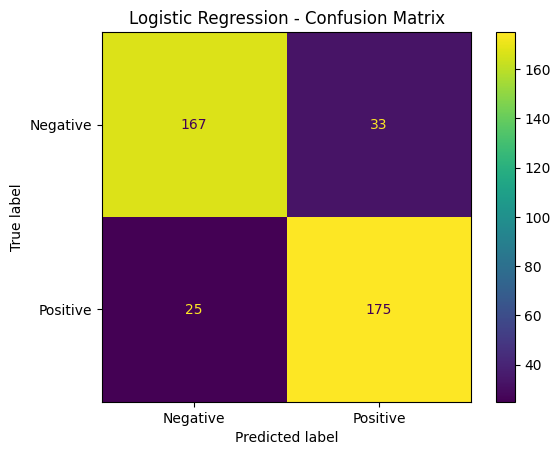

In [ ]:
# ============================================
# 6.5 Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["neg", "pos"]
)

print("Confusion Matrix:")
print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
# ============================================
# 6.5.1 Confusion Matrix Breakdown
# ============================================

tn, fp, fn, tp = cm_lr.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 167
False Positives: 33
False Negatives: 25
True Positives : 175


#### Confusion Matrix Summary

The confusion matrix provides a detailed breakdown of the Logistic Regression
classification results on the 400 held-out test reviews.

The model correctly classified 167 negative reviews and 175 positive reviews,
resulting in 342 correct predictions. It incorrectly classified 33 negative
reviews as positive (false positives) and 25 positive reviews as negative
(false negatives), resulting in 58 classification errors.

The number of false positives is slightly higher than the number of false
negatives. This is consistent with the earlier evaluation results, where
precision (84.13%) was lower than recall (87.50%).

Overall, the confusion matrix confirms that the model successfully identifies
both sentiment classes while still making a relatively small number of
classification errors.

### 6.6 Baseline Interpretation

The TF-IDF + Logistic Regression pipeline achieved 85.50% accuracy and an
F1-score of 85.78% on the held-out test set. Precision was 84.13% and recall
was 87.50%.

The confusion matrix shows 342 correct classifications out of 400 test
reviews, with 33 false positives and 25 false negatives. The relatively
similar numbers of false positives and false negatives indicate that the
model is not strongly biased toward only one sentiment class.

The model also required only 0.4909 seconds to train, providing a
computationally efficient baseline for comparison with the later approaches.

This establishes the Traditional ML baseline for the project. The same
held-out test set and evaluation metrics will be used for the LSTM and VADER
pipelines so that their predictive performance and computational
characteristics can be compared consistently.

## Section 7: LSTM

### 7.1 LSTM Data Preparation

For the neural network pipeline, the cleaned movie reviews are converted
from text into integer sequences suitable for an LSTM.

Unlike the TF-IDF representation used in the traditional machine learning
pipeline, the LSTM processes the reviews as ordered sequences of tokens. A
vocabulary is learned from the training reviews, and each token is mapped to
an integer index.

The vocabulary is constructed using the training reviews only. The same
mapping is then applied to the held-out test reviews to prevent information
leakage from the test set.

#### 7.1.1 Tokenization and Vocabulary

In [ ]:
# ============================================
# 7.1.1 Tokenization and Vocabulary
# ============================================

from collections import Counter

# Tokenize using whitespace because the preprocessing stage
# has already cleaned and normalized the reviews.
train_tokens = [review.split() for review in X_train_clean]
test_tokens = [review.split() for review in X_test_clean]

# Build vocabulary ONLY from training reviews.
token_counter = Counter(
    token
    for review_tokens in train_tokens
    for token in review_tokens
)

# Reserve index 0 for padding.
# Reserve index 1 for unknown/out-of-vocabulary tokens.
PAD_IDX = 0
UNK_IDX = 1

word_to_idx = {
    word: idx
    for idx, (word, _) in enumerate(
        token_counter.most_common(),
        start=2
    )
}

vocab_size = len(word_to_idx) + 2

print("Tokenization completed successfully.")
print("Training reviews tokenized:", len(train_tokens))
print("Test reviews tokenized:", len(test_tokens))
print("Unique vocabulary words:", len(word_to_idx))
print("Total vocabulary size including PAD/UNK:", vocab_size)
print("PAD index:", PAD_IDX)
print("UNK index:", UNK_IDX)

Tokenization completed successfully.
Training reviews tokenized: 1600
Test reviews tokenized: 400
Unique vocabulary words: 35540
Total vocabulary size including PAD/UNK: 35542
PAD index: 0
UNK index: 1


#### 7.1.2 Review Length and Sequence Length

In [ ]:
# ============================================
# 7.1.2 Review Length Distribution
# ============================================

import numpy as np

train_sequence_lengths = np.array([
    len(tokens) for tokens in train_tokens
])

test_sequence_lengths = np.array([
    len(tokens) for tokens in test_tokens
])

percentiles = [50, 75, 80, 85, 90, 95, 99]

print("Training sequence length percentiles:")
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(train_sequence_lengths, p):.0f}")

print("\nTraining maximum sequence length:",
      train_sequence_lengths.max())

print("Test maximum sequence length:",
      test_sequence_lengths.max())

Training sequence length percentiles:
50th percentile: 335
75th percentile: 431
80th percentile: 459
85th percentile: 492
90th percentile: 541
95th percentile: 643
99th percentile: 840

Training maximum sequence length: 1401
Test maximum sequence length: 1218


#### LSTM Data Preparation Summary

The tokenized training reviews have a median length of 335 tokens, while the
75th, 85th, 90th, 95th, and 99th percentiles are 431, 492, 541, 643, and
840 tokens respectively. The maximum training review length is 1,401 tokens.

Based on this observed distribution, a maximum sequence length of 500 tokens
is selected for the LSTM. This value is close to the 85th percentile of the
training sequence-length distribution and therefore retains the complete
sequence for approximately 85% of the training reviews without requiring
excessive padding.

Reviews longer than 500 tokens will be truncated, while shorter reviews will
be padded. This provides a practical balance between retaining review
content and controlling the computational cost of processing long sequences.

#### 7.1.3 Padding and Truncation

Each tokenized review is converted into a sequence of integer indices using
the vocabulary learned from the training data.

The maximum sequence length is set to 500 tokens. Reviews shorter than this
length are padded with the reserved PAD index, while reviews longer than
500 tokens are truncated.

Unknown words encountered in the test set that are not present in the
training vocabulary are represented using the reserved UNK index. This
ensures that the test representation does not introduce new vocabulary
information.

In [ ]:
# ============================================
# 7.1.3 Convert Tokens to Integer Sequences
# ============================================

MAX_LEN = 500

def tokens_to_indices(tokenized_reviews, word_to_idx):
    sequences = []

    for tokens in tokenized_reviews:
        sequence = [
            word_to_idx.get(token, UNK_IDX)
            for token in tokens
        ]
        sequences.append(sequence)

    return sequences


train_sequences = tokens_to_indices(
    train_tokens,
    word_to_idx
)

test_sequences = tokens_to_indices(
    test_tokens,
    word_to_idx
)

print("Integer sequence conversion completed.")
print("Training sequences:", len(train_sequences))
print("Test sequences:", len(test_sequences))
print("Maximum sequence length selected:", MAX_LEN)

Integer sequence conversion completed.
Training sequences: 1600
Test sequences: 400
Maximum sequence length selected: 500


In [ ]:
# ============================================
# 7.1.3.1 Apply Padding and Truncation
# ============================================

def pad_or_truncate(sequences, max_len, pad_idx=0):
    padded_sequences = []

    for sequence in sequences:

        # Truncate sequences longer than max_len
        if len(sequence) > max_len:
            sequence = sequence[:max_len]

        # Pad sequences shorter than max_len
        elif len(sequence) < max_len:
            sequence = sequence + [pad_idx] * (max_len - len(sequence))

        padded_sequences.append(sequence)

    return np.array(padded_sequences, dtype=np.int64)


X_train_lstm = pad_or_truncate(
    train_sequences,
    MAX_LEN,
    PAD_IDX
)

X_test_lstm = pad_or_truncate(
    test_sequences,
    MAX_LEN,
    PAD_IDX
)

print("Padding and truncation completed.")
print("Training LSTM input shape:", X_train_lstm.shape)
print("Test LSTM input shape:", X_test_lstm.shape)

Padding and truncation completed.
Training LSTM input shape: (1600, 500)
Test LSTM input shape: (400, 500)


#### 7.1.4 Verify Padding and Truncation

In [ ]:
# ============================================
# 7.1.4 Verify LSTM Input Preparation
# ============================================

print("Training input shape:", X_train_lstm.shape)
print("Test input shape:", X_test_lstm.shape)

print("\nExpected training shape:",
      (len(X_train_clean), MAX_LEN))

print("Expected test shape:",
      (len(X_test_clean), MAX_LEN))

print("\nTraining shape correct:",
      X_train_lstm.shape == (len(X_train_clean), MAX_LEN))

print("Test shape correct:",
      X_test_lstm.shape == (len(X_test_clean), MAX_LEN))

# Count padding tokens
train_padding_count = (X_train_lstm == PAD_IDX).sum()
test_padding_count = (X_test_lstm == PAD_IDX).sum()

print("\nTraining padding tokens:", train_padding_count)
print("Test padding tokens:", test_padding_count)

Training input shape: (1600, 500)
Test input shape: (400, 500)

Expected training shape: (1600, 500)
Expected test shape: (400, 500)

Training shape correct: True
Test shape correct: True

Training padding tokens: 257451
Test padding tokens: 65738


#### 7.1.5 Tensor Preparation

The padded and truncated integer sequences are converted into PyTorch tensors
so that they can be supplied to the LSTM neural network.

The training and test inputs retain the dimensions established during
padding, with each review represented as a sequence of 500 token indices.

The sentiment labels are also converted into numerical targets, with
negative reviews represented by 0 and positive reviews represented by 1.
The same label mapping is used consistently throughout the LSTM pipeline.

In [ ]:
# ============================================
# 7.1.5 Convert Data to PyTorch Tensors
# ============================================

import torch

# Convert sentiment labels to numerical values
label_to_idx = {
    "neg": 0,
    "pos": 1
}

y_train_lstm = np.array([
    label_to_idx[label]
    for label in y_train
])

y_test_lstm = np.array([
    label_to_idx[label]
    for label in y_test
])

# Convert inputs and labels to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_lstm,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_lstm,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train_lstm,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_lstm,
    dtype=torch.long
)

print("PyTorch tensor conversion completed.")
print("Training input tensor shape:", X_train_tensor.shape)
print("Test input tensor shape:", X_test_tensor.shape)
print("Training label tensor shape:", y_train_tensor.shape)
print("Test label tensor shape:", y_test_tensor.shape)

print("\nLabel mapping:", label_to_idx)
print("Training tensor dtype:", X_train_tensor.dtype)
print("Label tensor dtype:", y_train_tensor.dtype)

PyTorch tensor conversion completed.
Training input tensor shape: torch.Size([1600, 500])
Test input tensor shape: torch.Size([400, 500])
Training label tensor shape: torch.Size([1600])
Test label tensor shape: torch.Size([400])

Label mapping: {'neg': 0, 'pos': 1}
Training tensor dtype: torch.int64
Label tensor dtype: torch.int64


#### 7.1.6 Final LSTM Data Preparation Verification

In [ ]:
# ============================================
# 7.1.6 Final LSTM Data Preparation Verification
# ============================================

print("Training input shape:", X_train_tensor.shape)
print("Test input shape:", X_test_tensor.shape)

print("\nTraining labels:", len(y_train_tensor))
print("Test labels:", len(y_test_tensor))

print("\nTraining input/label alignment:",
      len(X_train_tensor) == len(y_train_tensor))

print("Test input/label alignment:",
      len(X_test_tensor) == len(y_test_tensor))

print("\nTraining label distribution:")
print(torch.bincount(y_train_tensor))

print("\nTest label distribution:")
print(torch.bincount(y_test_tensor))

Training input shape: torch.Size([1600, 500])
Test input shape: torch.Size([400, 500])

Training labels: 1600
Test labels: 400

Training input/label alignment: True
Test input/label alignment: True

Training label distribution:
tensor([800, 800])

Test label distribution:
tensor([200, 200])


### 7.1 LSTM Data Preparation — Conclusion

The cleaned movie reviews were converted into integer token sequences using a
vocabulary constructed exclusively from the training data. The resulting
vocabulary contained 35,540 unique words, with separate reserved indices for
padding and unknown tokens.

Based on the observed training review-length distribution, a maximum sequence
length of 500 tokens was selected. This value is close to the 85th percentile
of the training sequence-length distribution, providing a practical balance
between retaining review content and controlling computational cost.

The sequences were padded or truncated to 500 tokens and converted into
PyTorch tensors. The resulting training and test input tensors have shapes
(1,600, 500) and (400, 500), respectively. The label tensors contain 1,600
and 400 observations, with negative sentiment encoded as 0 and positive
sentiment as 1.

The final verification confirms correct input-label alignment and preserves
the balanced class distribution of the original train/test split. The
prepared tensors are therefore ready for the LSTM architecture.

### 7.2 LSTM Architecture

The LSTM model is designed to process the ordered token sequences produced
during the data-preparation stage.

The architecture consists of an embedding layer, a recurrent LSTM layer, a
dropout layer, and a fully connected output layer. The embedding layer maps
integer token indices into dense 128-dimensional vectors. The LSTM layer
processes the resulting sequence and learns contextual information across
the review.

The final hidden representation is passed through dropout before being
given to a fully connected output layer that produces a single value for
binary sentiment classification.

The architecture is intentionally kept compact because the dataset contains
1,600 training reviews and the objective is to establish a meaningful neural
network comparison rather than maximize architectural complexity.

#### 7.2.1 Define LSTM Architecture

In [ ]:
# ============================================
# 7.2.1 Define LSTM Architecture
# ============================================

import torch.nn as nn

class SentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        dropout=0.30,
        pad_idx=0
    ):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        # Recurrent LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        # Convert token IDs into dense vectors
        embedded = self.embedding(x)

        # Process the sequence using LSTM
        lstm_output, (hidden, cell) = self.lstm(embedded)

        # Use the final hidden state
        final_hidden = hidden[-1]

        # Apply dropout
        dropped = self.dropout(final_hidden)

        # Binary classification output
        output = self.fc(dropped)

        return output.squeeze(1)

#### 7.2.2 Instantiate the LSTM Model

In [ ]:
# ============================================
# 7.2.2 Instantiate LSTM Model
# ============================================

EMBEDDING_DIM = 128
HIDDEN_DIM = 128
DROPOUT = 0.30

lstm_model = SentimentLSTM(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
)

# Use the same device selected earlier
lstm_model = lstm_model.to(device)

print("LSTM model created successfully.")
print("Vocabulary size:", vocab_size)
print("Embedding dimension:", EMBEDDING_DIM)
print("Hidden dimension:", HIDDEN_DIM)
print("Dropout:", DROPOUT)
print("Device:", device)

LSTM model created successfully.
Vocabulary size: 35542
Embedding dimension: 128
Hidden dimension: 128
Dropout: 0.3
Device: cpu


#### 7.2.3 Display LSTM Architecture

In [ ]:
# ============================================
# 7.2.3 Display LSTM Architecture
# ============================================

print(lstm_model)

SentimentLSTM(
  (embedding): Embedding(35542, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


#### 7.2.4 Count Trainable Parameters

In [ ]:
# ============================================
# 7.2.4 Count Trainable Parameters
# ============================================

trainable_parameters = sum(
    parameter.numel()
    for parameter in lstm_model.parameters()
    if parameter.requires_grad
)

print("Total trainable parameters:", trainable_parameters)

Total trainable parameters: 4681601


#### 7.2.5 Architecture Interpretation

The LSTM architecture contains an embedding layer that converts the integer
token indices into 128-dimensional dense representations. These embeddings
are passed to a single LSTM layer with 128 hidden units, allowing the model
to process the sequential structure of each review.

A dropout rate of 0.30 is applied to the final hidden representation before
the fully connected output layer. The output layer contains one neuron,
which produces a single score for the binary sentiment classification task.

The model contains 4,681,601 trainable parameters. Given the relatively
small training set of 1,600 reviews, training performance and validation
behavior will be monitored carefully for evidence of overfitting.

### 7.3 LSTM Training

The LSTM is trained using the training portion of the dataset, while a
validation subset is held out from the training data to monitor learning
behavior and potential overfitting.

The original 400-review test set remains untouched until final evaluation.
This ensures that model-selection and training decisions do not use
information from the final test set.

The training data is divided into 80% training and 20% validation subsets,
resulting in 1,280 training reviews and 320 validation reviews.

#### 7.3.1 Training and Validation Split

In [ ]:
# ============================================
# 7.3.1 Training and Validation Split
# ============================================

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Create index positions for the 1,600 training samples
train_indices = np.arange(len(X_train_tensor))

train_idx, val_idx = train_test_split(
    train_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_train_lstm
)

# Split the tensors
X_train_sub = X_train_tensor[train_idx]
X_val = X_train_tensor[val_idx]

y_train_sub = y_train_tensor[train_idx]
y_val = y_train_tensor[val_idx]

print("Training subset:", X_train_sub.shape)
print("Validation subset:", X_val.shape)
print("Held-out test set:", X_test_tensor.shape)

print("\nTraining subset labels:", y_train_sub.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test_tensor.shape)

print("\nTraining class distribution:")
print(torch.bincount(y_train_sub))

print("\nValidation class distribution:")
print(torch.bincount(y_val))

Training subset: torch.Size([1280, 500])
Validation subset: torch.Size([320, 500])
Held-out test set: torch.Size([400, 500])

Training subset labels: torch.Size([1280])
Validation labels: torch.Size([320])
Test labels: torch.Size([400])

Training class distribution:
tensor([640, 640])

Validation class distribution:
tensor([160, 160])


#### 7.3.2 Create PyTorch DataLoaders

PyTorch DataLoaders are used to divide the training and validation tensors
into mini-batches. Mini-batch training reduces memory requirements and
allows the model parameters to be updated repeatedly during each training
epoch.

The test set is also placed in a DataLoader, but it will remain unused until
the final evaluation stage.

In [ ]:
# ============================================
# 7.3.2 Create DataLoaders
# ============================================

BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_sub,
    y_train_sub
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.
Batch size: 32
Training batches: 40
Validation batches: 10
Test batches: 13


#### 7.3.3 Training Configuration

Binary Cross Entropy with Logits Loss is used because the model produces a
single output value for the binary sentiment classification task. The loss
function combines the sigmoid transformation and binary cross-entropy
calculation in a numerically stable form.

The Adam optimizer is used to update the model parameters. A learning rate
of 0.001 is selected as the initial optimization setting.

Training is allowed for a maximum of 10 epochs, while validation loss is
monitored after each epoch. Early stopping will be used to reduce the risk of
overfitting, which is particularly relevant because the model contains more
than four million trainable parameters compared with the relatively small
training dataset.

In [ ]:
# ============================================
# 7.3.3 Training Configuration
# ============================================

import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

MAX_EPOCHS = 10
PATIENCE = 2

print("Training configuration created successfully.")
print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 0.001)
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)

Training configuration created successfully.
Loss function: BCEWithLogitsLoss()
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 10
Early stopping patience: 2


#### 7.3.4 LSTM Model Training

The LSTM is trained using mini-batch gradient-based optimization. During each
epoch, the model parameters are updated using the training batches and
Binary Cross Entropy with Logits loss.

After each epoch, the model is evaluated on the validation subset without
updating its parameters. Training and validation loss and accuracy are
recorded to assess learning behavior and identify potential overfitting.

Early stopping is applied using validation loss. If validation loss does not
improve for the specified patience period, training is stopped. The model
parameters corresponding to the lowest validation loss are restored before
final testing.

In [ ]:
# ============================================
# 7.3.4 Train LSTM Model
# ============================================

import time
import copy

# Store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Track best validation performance
best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

# Start training timer
training_start_time = time.time()

for epoch in range(MAX_EPOCHS):

    # ----------------------------------------
    # Training phase
    # ----------------------------------------
    lstm_model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.float().to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = lstm_model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Accumulate loss
        running_train_loss += loss.item() * inputs.size(0)

        # Convert logits to predictions
        predictions = (torch.sigmoid(outputs) >= 0.5).long()

        correct_train += (
            predictions == labels.long()
        ).sum().item()

        total_train += labels.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = correct_train / total_train

    # ----------------------------------------
    # Validation phase
    # ----------------------------------------
    lstm_model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.float().to(device)

            # Forward pass
            outputs = lstm_model(inputs)

            # Calculate validation loss
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            # Convert logits to predictions
            predictions = (torch.sigmoid(outputs) >= 0.5).long()

            correct_val += (
                predictions == labels.long()
            ).sum().item()

            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = correct_val / total_val

    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

    # Print epoch results
    print(
        f"Epoch {epoch + 1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f}"
    )

    # ----------------------------------------
    # Early stopping / best model tracking
    # ----------------------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(
            lstm_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered after "
                f"{epoch + 1} epochs."
            )

            break


# Calculate total training time
training_time = time.time() - training_start_time

# Restore best validation model
if best_model_state is not None:
    lstm_model.load_state_dict(best_model_state)

print("\nLSTM training completed.")
print(f"Training time: {training_time:.4f} seconds")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best epoch: {np.argmin(val_losses) + 1}")

Epoch 01/10 | Train Loss: 0.6922 | Train Acc: 0.5172 | Val Loss: 0.6917 | Val Acc: 0.5250
Epoch 02/10 | Train Loss: 0.6779 | Train Acc: 0.5742 | Val Loss: 0.6903 | Val Acc: 0.5188
Epoch 03/10 | Train Loss: 0.7800 | Train Acc: 0.5656 | Val Loss: 0.6927 | Val Acc: 0.5156
Epoch 04/10 | Train Loss: 0.6622 | Train Acc: 0.5930 | Val Loss: 0.6934 | Val Acc: 0.5156

Early stopping triggered after 4 epochs.

LSTM training completed.
Training time: 624.6392 seconds
Best validation loss: 0.6903
Best epoch: 2


#### 7.3.5 Training History Summary

In [ ]:
# ============================================
# 7.3.5 Summarize Training History
# ============================================

history_df = pd.DataFrame({
    "Epoch": range(1, len(train_losses) + 1),
    "Training Loss": train_losses,
    "Validation Loss": val_losses,
    "Training Accuracy": train_accuracies,
    "Validation Accuracy": val_accuracies
})

print(history_df.to_string(index=False))

print("\nNumber of epochs completed:", len(history_df))
print("Best validation loss:", min(val_losses))
print(
    "Best validation accuracy:",
    max(val_accuracies)
)
print(
    "Epoch with best validation accuracy:",
    np.argmax(val_accuracies) + 1
)

 Epoch  Training Loss  Validation Loss  Training Accuracy  Validation Accuracy
     1       0.692175         0.691734           0.517188             0.525000
     2       0.677879         0.690300           0.574219             0.518750
     3       0.779997         0.692671           0.565625             0.515625
     4       0.662234         0.693407           0.592969             0.515625

Number of epochs completed: 4
Best validation loss: 0.6902997314929962
Best validation accuracy: 0.525
Epoch with best validation accuracy: 1


#### 7.3.6 Initial LSTM Training Observations

The initial LSTM training run was completed with a maximum of 10 epochs and
early stopping patience of 2. Training stopped after 4 epochs because the
validation loss did not improve for two consecutive epochs.

The training accuracy increased from 51.72% in Epoch 1 to 59.30% in Epoch 4.
However, validation accuracy remained close to chance level, decreasing from
52.50% in Epoch 1 to 51.56% by Epoch 4. The best validation loss was 0.6903,
achieved at Epoch 2, while the best validation accuracy was 52.50%, achieved
at Epoch 1.

These results indicate that the initial LSTM configuration did not learn
patterns that generalized effectively to the validation data. The increase
in training accuracy without a corresponding improvement in validation
accuracy suggests weak generalization and early signs of overfitting or
unstable learning. However, the relatively low training accuracy means that
strong overfitting cannot be concluded from this run alone.

The early-stopping mechanism correctly identified the lack of continued
validation improvement and restored the model parameters associated with the
lowest validation loss.

Because the initial run was performed on the CPU and required substantial
training time, the computational environment will be checked before making
any changes to the model architecture or hyperparameters. This provides a
controlled next step and avoids changing multiple experimental factors at
once.

#### 7.3.7 Computational Environment Check

The initial LSTM run required several minutes per epoch on the CPU. Before
changing the model architecture or training configuration, GPU availability
will be checked.

If a GPU is available, the same LSTM configuration will first be evaluated
using GPU acceleration. This isolates the effect of the computational
environment before considering any changes to the model or hyperparameters.

In [ ]:
# ============================================
# Check GPU Availability
# ============================================

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available. Current device:", device)

PyTorch version: 2.11.0+cpu
CUDA available: False
No GPU available. Current device: cpu


## 7.4 LSTM Configuration Refinement

### 7.4.1 Rationale for Sequence Length Refinement

The initial LSTM configuration used a maximum sequence length of 500 tokens.
The training results showed weak validation performance, while the CPU-based
training process required substantial computation time.

The review-length analysis performed during sequence preparation showed the
following training sequence length percentiles:

- 50th percentile: 335 tokens
- 75th percentile: 431 tokens
- 80th percentile: 459 tokens
- 85th percentile: 492 tokens
- 90th percentile: 541 tokens
- 95th percentile: 643 tokens

Based on these observed statistics, a maximum sequence length of 400 tokens
is selected for a controlled refinement experiment. This value remains close
to the central range of review lengths while reducing the number of sequential
time steps processed by the LSTM.

The objective of this refinement is primarily computational efficiency while
retaining the same overall LSTM architecture and learning configuration.
Other major model and training parameters are kept unchanged so that the
effect of the sequence-length adjustment can be evaluated more clearly.

The original 500-token experiment is retained as the initial configuration
and is not overwritten.

### 7.4.2 Refined Sequence Length

The refined LSTM experiment uses a maximum sequence length of 400 tokens.
Reviews longer than this limit are truncated, while shorter reviews are
padded using the PAD token.

The same training and test reviews are used as in the initial experiment.
The test set remains completely untouched during model development.

In [ ]:
# ============================================
# 7.4.2 Refined Sequence Length
# ============================================

REFINED_MAX_LEN = 400

print("Initial maximum sequence length:", MAX_LEN)
print("Refined maximum sequence length:", REFINED_MAX_LEN)

Initial maximum sequence length: 500
Refined maximum sequence length: 400


### 7.4.3 Apply Padding and Truncation

The tokenized training and test sequences are converted into fixed-length
sequences using the refined maximum length of 400 tokens.

The same padding and truncation procedure used in the initial experiment is
applied here to maintain consistency.

In [ ]:
# ============================================
# 7.4.3 Apply Refined Padding and Truncation
# ============================================

X_train_lstm_refined = pad_or_truncate(
    train_sequences,
    REFINED_MAX_LEN,
    PAD_IDX
)

X_test_lstm_refined = pad_or_truncate(
    test_sequences,
    REFINED_MAX_LEN,
    PAD_IDX
)

print("Refined padding and truncation completed.")

print(
    "Training refined LSTM input shape:",
    X_train_lstm_refined.shape
)

print(
    "Test refined LSTM input shape:",
    X_test_lstm_refined.shape
)

Refined padding and truncation completed.
Training refined LSTM input shape: (1600, 400)
Test refined LSTM input shape: (400, 400)


### 7.4.4 Verify Refined Sequence Preparation

The refined sequence dimensions and padding counts are checked before
creating the PyTorch tensors. This confirms that the revised sequence length
has been applied consistently to both training and test inputs.

In [ ]:
# ============================================
# 7.4.4 Verify Refined Sequence Preparation
# ============================================

train_refined_padding_count = (
    X_train_lstm_refined == PAD_IDX
).sum()

test_refined_padding_count = (
    X_test_lstm_refined == PAD_IDX
).sum()

print("Training refined input shape:", X_train_lstm_refined.shape)
print("Test refined input shape:", X_test_lstm_refined.shape)

print(
    "\nExpected training shape:",
    (len(X_train_clean), REFINED_MAX_LEN)
)

print(
    "Expected test shape:",
    (len(X_test_clean), REFINED_MAX_LEN)
)

print(
    "\nTraining shape correct:",
    X_train_lstm_refined.shape ==
    (len(X_train_clean), REFINED_MAX_LEN)
)

print(
    "Test shape correct:",
    X_test_lstm_refined.shape ==
    (len(X_test_clean), REFINED_MAX_LEN)
)

print("\nTraining padding tokens:", train_refined_padding_count)
print("Test padding tokens:", test_refined_padding_count)

Training refined input shape: (1600, 400)
Test refined input shape: (400, 400)

Expected training shape: (1600, 400)
Expected test shape: (400, 400)

Training shape correct: True
Test shape correct: True

Training padding tokens: 132735
Test padding tokens: 35092


### 7.4.5 Convert Refined Data to PyTorch Tensors

The refined padded sequences are converted into PyTorch tensors using the
same label encoding as the initial LSTM experiment:

- Negative sentiment = 0
- Positive sentiment = 1

The labels are not changed because only the sequence-length configuration is
being refined.

In [ ]:
# ============================================
# 7.4.5 Convert Refined Data to PyTorch Tensors
# ============================================

X_train_refined_tensor = torch.tensor(
    X_train_lstm_refined,
    dtype=torch.long
)

X_test_refined_tensor = torch.tensor(
    X_test_lstm_refined,
    dtype=torch.long
)

y_train_refined_tensor = torch.tensor(
    y_train.map({"neg": 0, "pos": 1}).values,
    dtype=torch.long
)

y_test_refined_tensor = torch.tensor(
    y_test.map({"neg": 0, "pos": 1}).values,
    dtype=torch.long
)

print("Refined PyTorch tensor conversion completed.")

print(
    "Training input tensor shape:",
    X_train_refined_tensor.shape
)

print(
    "Test input tensor shape:",
    X_test_refined_tensor.shape
)

print(
    "Training label tensor shape:",
    y_train_refined_tensor.shape
)

print(
    "Test label tensor shape:",
    y_test_refined_tensor.shape
)

print(
    "\nLabel mapping:",
    {"neg": 0, "pos": 1}
)

Refined PyTorch tensor conversion completed.
Training input tensor shape: torch.Size([1600, 400])
Test input tensor shape: torch.Size([400, 400])
Training label tensor shape: torch.Size([1600])
Test label tensor shape: torch.Size([400])

Label mapping: {'neg': 0, 'pos': 1}


### 7.4.6 Training and Validation Split

The refined experiment uses the same 1,600-review training dataset and
separates 20% of it for validation. The 400-review test set remains isolated
and is not used for model selection or hyperparameter decisions.

The same random seed is used to maintain reproducibility.

In [ ]:
# ============================================
# 7.4.6 Create Refined Training/Validation Split
# ============================================

from torch.utils.data import TensorDataset, DataLoader, random_split

# Create complete refined training dataset
refined_full_dataset = TensorDataset(
    X_train_refined_tensor,
    y_train_refined_tensor
)

# Same 80/20 split
refined_train_size = int(0.8 * len(refined_full_dataset))
refined_val_size = len(refined_full_dataset) - refined_train_size

# Reproducible split
split_generator = torch.Generator().manual_seed(42)

refined_train_dataset, refined_val_dataset = random_split(
    refined_full_dataset,
    [refined_train_size, refined_val_size],
    generator=split_generator
)

print("Refined training samples:", len(refined_train_dataset))
print("Refined validation samples:", len(refined_val_dataset))
print("Final test samples:", len(X_test_refined_tensor))

Refined training samples: 1280
Refined validation samples: 320
Final test samples: 400


### 7.4.7 Refined DataLoaders

DataLoaders are created using the same batch size of 32 as the initial
experiment. Keeping the batch size unchanged allows the sequence-length
adjustment to remain the primary experimental change.

In [ ]:
# ============================================
# 7.4.7 Create Refined DataLoaders
# ============================================

BATCH_SIZE_REFINED = 32

refined_train_loader = DataLoader(
    refined_train_dataset,
    batch_size=BATCH_SIZE_REFINED,
    shuffle=True
)

refined_val_loader = DataLoader(
    refined_val_dataset,
    batch_size=BATCH_SIZE_REFINED,
    shuffle=False
)

refined_test_dataset = TensorDataset(
    X_test_refined_tensor,
    y_test_refined_tensor
)

refined_test_loader = DataLoader(
    refined_test_dataset,
    batch_size=BATCH_SIZE_REFINED,
    shuffle=False
)

print("Refined DataLoaders created successfully.")

print("Batch size:", BATCH_SIZE_REFINED)
print("Training batches:", len(refined_train_loader))
print("Validation batches:", len(refined_val_loader))
print("Test batches:", len(refined_test_loader))

Refined DataLoaders created successfully.
Batch size: 32
Training batches: 40
Validation batches: 10
Test batches: 13


### 7.4.8 Refinement Preparation Observation

The refined sequence preparation was completed successfully using a maximum
sequence length of 400 tokens.

The resulting training and test inputs have shapes of (1600, 400) and
(400, 400), respectively. The training data was further divided into 1,280
training samples and 320 validation samples, while the 400-sample test set
remained isolated for final evaluation.

Reducing the maximum sequence length from 500 to 400 also reduced the number
of padding tokens in the training data from 257,451 to 132,735. This
represents a substantial reduction in unnecessary padded time steps while
retaining the same underlying reviews and labels.

The refined experiment therefore changes the sequence-length configuration
while keeping the dataset split, label encoding, batch size, and overall
experimental methodology consistent with the initial LSTM experiment.

### 7.4.9 Refined LSTM Architecture

The refined LSTM retains the same neural architecture used in the initial
experiment. The maximum sequence length is reduced from 500 to 400 tokens,
while the model architecture and its major hyperparameters remain unchanged.

The model uses:

- Vocabulary size: 35,542 including PAD and UNK tokens
- Embedding dimension: 128
- LSTM hidden dimension: 128
- Number of LSTM layers: 1
- Dropout: 0.30
- Output layer: single neuron for binary sentiment classification
- PAD index: 0

Keeping the architecture unchanged allows the refined experiment to evaluate
the effect of the shorter sequence length without simultaneously changing
model capacity.

In [ ]:
# ============================================
# 7.4.9 Define Refined LSTM Architecture
# ============================================

class SentimentLSTMRefined(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        padding_idx=0
    ):
        super(SentimentLSTMRefined, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        # Use the final hidden state
        hidden = hidden[-1]

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output.squeeze(1)


# Create refined model
lstm_model_refined = SentimentLSTMRefined(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=128,
    dropout=0.3,
    padding_idx=PAD_IDX
).to(device)

print("Refined LSTM model created successfully.")
print("Vocabulary size:", vocab_size)
print("Embedding dimension:", 128)
print("Hidden dimension:", 128)
print("Dropout:", 0.3)
print("Maximum sequence length:", REFINED_MAX_LEN)
print("Device:", device)

Refined LSTM model created successfully.
Vocabulary size: 35542
Embedding dimension: 128
Hidden dimension: 128
Dropout: 0.3
Maximum sequence length: 400
Device: cpu


### 7.4.10 Display Refined LSTM Architecture


In [ ]:
# ============================================
# 7.4.10 Display Refined LSTM Architecture
# ============================================

print(lstm_model_refined)

refined_trainable_parameters = sum(
    parameter.numel()
    for parameter in lstm_model_refined.parameters()
    if parameter.requires_grad
)

print(
    "\nTotal trainable parameters:",
    refined_trainable_parameters
)

SentimentLSTMRefined(
  (embedding): Embedding(35542, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total trainable parameters: 4681601


### 7.4.11 Refined Loss Function and Optimizer

The refined LSTM uses the same loss function and optimization settings as the
initial LSTM experiment.

Binary Cross Entropy with Logits Loss (BCEWithLogitsLoss) is used because the
task is binary sentiment classification. The Adam optimizer is used with a
learning rate of 0.001.

The maximum number of training epochs remains 10, with early stopping
patience set to 2 epochs.

Keeping these settings unchanged supports a controlled comparison between the
initial 500-token experiment and the refined 400-token experiment.

In [ ]:
# ============================================
# 7.4.11 Refined Loss Function and Optimizer
# ============================================

criterion_refined = nn.BCEWithLogitsLoss()

optimizer_refined = torch.optim.Adam(
    lstm_model_refined.parameters(),
    lr=0.001
)

MAX_EPOCHS_REFINED = 10
PATIENCE_REFINED = 2

print("Refined training configuration created successfully.")
print("Loss function:", criterion_refined)
print("Optimizer: Adam")
print("Learning rate:", 0.001)
print("Maximum epochs:", MAX_EPOCHS_REFINED)
print("Early stopping patience:", PATIENCE_REFINED)

Refined training configuration created successfully.
Loss function: BCEWithLogitsLoss()
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 10
Early stopping patience: 2


### 7.4.12 Refined LSTM Training

The refined LSTM is trained using the revised maximum sequence length of
400 tokens.

The training procedure remains consistent with the initial LSTM experiment:
the same training/validation split, batch size, loss function, optimizer,
learning rate, maximum number of epochs, and early stopping strategy are
used.

Training and validation loss and accuracy are recorded after each epoch.
The model state corresponding to the lowest validation loss is retained.

The final test set of 400 reviews remains completely untouched during model
training and model selection and will only be used for final evaluation.

In [ ]:
# ============================================
# 7.4.12 Train Refined LSTM
# ============================================

import time
import copy

# History containers
refined_train_losses = []
refined_val_losses = []
refined_train_accuracies = []
refined_val_accuracies = []

# Best model tracking
best_refined_val_loss = float("inf")
best_refined_model_state = None
refined_epochs_without_improvement = 0

# Start timer
refined_training_start_time = time.time()

for epoch in range(MAX_EPOCHS_REFINED):

    # ----------------------------------------
    # Training phase
    # ----------------------------------------
    lstm_model_refined.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in refined_train_loader:

        inputs = inputs.to(device)
        labels = labels.float().to(device)

        optimizer_refined.zero_grad()

        outputs = lstm_model_refined(inputs)

        loss = criterion_refined(
            outputs,
            labels
        )

        loss.backward()
        optimizer_refined.step()

        running_train_loss += (
            loss.item() * inputs.size(0)
        )

        predictions = (
            torch.sigmoid(outputs) >= 0.5
        ).long()

        correct_train += (
            predictions == labels.long()
        ).sum().item()

        total_train += labels.size(0)

    epoch_train_loss = (
        running_train_loss / total_train
    )

    epoch_train_accuracy = (
        correct_train / total_train
    )

    # ----------------------------------------
    # Validation phase
    # ----------------------------------------
    lstm_model_refined.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for inputs, labels in refined_val_loader:

            inputs = inputs.to(device)
            labels = labels.float().to(device)

            outputs = lstm_model_refined(inputs)

            loss = criterion_refined(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * inputs.size(0)
            )

            predictions = (
                torch.sigmoid(outputs) >= 0.5
            ).long()

            correct_val += (
                predictions == labels.long()
            ).sum().item()

            total_val += labels.size(0)

    epoch_val_loss = (
        running_val_loss / total_val
    )

    epoch_val_accuracy = (
        correct_val / total_val
    )

    # Store history
    refined_train_losses.append(epoch_train_loss)
    refined_val_losses.append(epoch_val_loss)
    refined_train_accuracies.append(epoch_train_accuracy)
    refined_val_accuracies.append(epoch_val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{MAX_EPOCHS_REFINED} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f}"
    )

    # ----------------------------------------
    # Early stopping
    # ----------------------------------------
    if epoch_val_loss < best_refined_val_loss:

        best_refined_val_loss = epoch_val_loss

        best_refined_model_state = copy.deepcopy(
            lstm_model_refined.state_dict()
        )

        refined_epochs_without_improvement = 0

    else:

        refined_epochs_without_improvement += 1

        if refined_epochs_without_improvement >= PATIENCE_REFINED:

            print(
                f"\nEarly stopping triggered after "
                f"{epoch + 1} epochs."
            )

            break


# Training time
refined_training_time = (
    time.time() - refined_training_start_time
)

# Restore best validation model
if best_refined_model_state is not None:

    lstm_model_refined.load_state_dict(
        best_refined_model_state
    )

print("\nRefined LSTM training completed.")
print(
    f"Training time: "
    f"{refined_training_time:.4f} seconds"
)
print(
    f"Best validation loss: "
    f"{best_refined_val_loss:.4f}"
)
print(
    f"Best epoch: "
    f"{np.argmin(refined_val_losses) + 1}"
)

Epoch 01/10 | Train Loss: 0.6927 | Train Acc: 0.5195 | Val Loss: 0.6930 | Val Acc: 0.4969
Epoch 02/10 | Train Loss: 0.6725 | Train Acc: 0.6273 | Val Loss: 0.6899 | Val Acc: 0.5312
Epoch 03/10 | Train Loss: 0.6346 | Train Acc: 0.6461 | Val Loss: 0.7530 | Val Acc: 0.5344
Epoch 04/10 | Train Loss: 0.5858 | Train Acc: 0.6695 | Val Loss: 0.7211 | Val Acc: 0.5344

Early stopping triggered after 4 epochs.

Refined LSTM training completed.
Training time: 550.8902 seconds
Best validation loss: 0.6899
Best epoch: 2


### 7.4.13 Refined LSTM Training Observation

The refined LSTM experiment reduced the maximum sequence length from 500 to
400 tokens while keeping the model architecture, embedding dimension,
hidden dimension, dropout, optimizer, learning rate, batch size, and
early-stopping strategy unchanged.

The model completed four epochs before early stopping was triggered.

The best validation loss was **0.6899 at Epoch 2**, with a validation accuracy
of **53.13%**. Although training accuracy increased from **51.95% in Epoch 1**
to **66.95% in Epoch 4**, validation accuracy remained close to chance level
and reached only **53.44%**. At the same time, validation loss increased from
0.6899 in Epoch 2 to 0.7530 in Epoch 3 and 0.7211 in Epoch 4.

This divergence between improving training performance and weak validation
performance indicates that the model was beginning to overfit the training
data without achieving strong generalization.

Reducing the sequence length from 500 to 400 therefore did not produce a
substantial improvement in validation performance. However, the experiment
provides a useful controlled comparison and demonstrates why validation
performance, rather than training accuracy alone, should guide model
selection.

The refined LSTM required approximately **550.89 seconds** of training on
the available CPU environment. The final test set remains untouched and will
be used only for final model evaluation.

### 7.4.14 Initial vs Refined LSTM Comparison

The initial LSTM used a maximum sequence length of 500 tokens, while the
refined experiment reduced this to 400 tokens.

The purpose of this controlled experiment was to determine whether reducing
sequence length could improve validation performance and reduce unnecessary
computational processing while retaining sufficient information from each
review.

The refined experiment did not demonstrate a meaningful improvement in
validation accuracy. Its best validation accuracy was 53.13%, while the
validation loss reached its minimum at Epoch 2 before increasing in later
epochs.

Therefore, the sequence-length reduction alone was insufficient to resolve
the generalization problem observed in the LSTM pipeline.

The refined model will nevertheless be retained as the selected LSTM
configuration for final test-set evaluation because it represents the
controlled refinement performed during model development. The untouched
400-review test set will now be used to obtain the final out-of-sample
performance.

### 7.4.15 Final Refined LSTM Test Prediction

The refined LSTM model is evaluated on the untouched 20% test set containing
400 movie reviews.

The model selected during training based on the best validation loss is used
for prediction. No additional training or hyperparameter tuning is performed
using the test set.

The model outputs a sentiment logit for each review. The logits are converted
to probabilities using the sigmoid function and then converted into binary
sentiment predictions using a threshold of 0.5.

These predictions will be used for the final evaluation of the LSTM pipeline.

In [ ]:
# ============================================
# 7.4.15 Final Refined LSTM Test Prediction
# ============================================

# Put model into evaluation mode
lstm_model_refined.eval()

refined_test_predictions = []
refined_test_probabilities = []
refined_test_actuals = []

with torch.no_grad():

    for inputs, labels in refined_test_loader:

        inputs = inputs.to(device)

        # Model prediction
        outputs = lstm_model_refined(inputs)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        # Convert probabilities to binary predictions
        predictions = (probabilities >= 0.5).long()

        # Store results
        refined_test_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        refined_test_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        refined_test_actuals.extend(
            labels.cpu().numpy().flatten()
        )


print("Final refined LSTM test prediction completed.")

print(
    "Number of test predictions:",
    len(refined_test_predictions)
)

print(
    "Number of actual test labels:",
    len(refined_test_actuals)
)

print(
    "Prediction/label lengths match:",
    len(refined_test_predictions)
    == len(refined_test_actuals)
)

print("\nFirst 10 predicted labels:")

print([
    "pos" if p == 1 else "neg"
    for p in refined_test_predictions[:10]
])

print("\nFirst 10 actual labels:")

print([
    "pos" if a == 1 else "neg"
    for a in refined_test_actuals[:10]
])

Final refined LSTM test prediction completed.
Number of test predictions: 400
Number of actual test labels: 400
Prediction/label lengths match: True

First 10 predicted labels:
['neg', 'neg', 'neg', 'neg', 'neg', 'neg', 'neg', 'pos', 'pos', 'neg']

First 10 actual labels:
['neg', 'neg', 'pos', 'neg', 'neg', 'pos', 'pos', 'neg', 'neg', 'pos']


### 7.4.16 Test Prediction Class Distribution

The predicted sentiment distribution is examined to determine whether the
refined LSTM produces a reasonable balance of positive and negative
predictions on the test set.

This provides an additional diagnostic before calculating the final
evaluation metrics.

In [ ]:
# ============================================
# 7.4.16 Check Test Prediction Distribution
# ============================================

predicted_labels_refined = pd.Series(
    [
        "pos" if p == 1 else "neg"
        for p in refined_test_predictions
    ]
)

print("Refined LSTM predicted class distribution:")
print(predicted_labels_refined.value_counts())

print("\nRefined LSTM predicted class proportions:")
print(predicted_labels_refined.value_counts(normalize=True))

Refined LSTM predicted class distribution:
neg    299
pos    101
Name: count, dtype: int64

Refined LSTM predicted class proportions:
neg    0.7475
pos    0.2525
Name: proportion, dtype: float64


#### 7.4.16 Observation — Test Prediction Distribution

The refined LSTM produced 299 negative predictions and 101 positive
predictions on the 400-review test set.

This corresponds to **74.75% negative predictions and 25.25% positive
predictions**, whereas the actual test set contains an equal number of
positive and negative reviews (50% each).

The substantial difference between the predicted and actual class
distributions indicates that the refined LSTM has developed a strong bias
towards predicting the negative class.

This is an important diagnostic finding because a model can appear to achieve
reasonable accuracy while performing poorly for one of the sentiment classes.
Therefore, accuracy alone is insufficient for evaluating this model.

Precision, recall, F1-score, and the confusion matrix will be examined next
to determine the extent and practical impact of this prediction bias.

### 7.4.17 Final Refined LSTM Evaluation

The refined LSTM is evaluated on the untouched 400-review test set using
accuracy, precision, recall, and F1-score.

Accuracy measures overall classification correctness. Precision measures the
reliability of positive predictions, while recall measures the model's
ability to identify positive reviews correctly. The F1-score provides a
balance between precision and recall.

These metrics are calculated using the final test predictions and actual
test labels. A confusion matrix is also generated to examine the types of
classification errors made by the model.

In [ ]:
# ============================================
# 7.4.17 Final Refined LSTM Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Convert predictions and actual labels to NumPy arrays
y_test_refined = np.array(refined_test_actuals)
y_pred_refined = np.array(refined_test_predictions)

# Calculate evaluation metrics
refined_accuracy = accuracy_score(
    y_test_refined,
    y_pred_refined
)

refined_precision = precision_score(
    y_test_refined,
    y_pred_refined,
    zero_division=0
)

refined_recall = recall_score(
    y_test_refined,
    y_pred_refined,
    zero_division=0
)

refined_f1 = f1_score(
    y_test_refined,
    y_pred_refined,
    zero_division=0
)

# Confusion matrix
refined_cm = confusion_matrix(
    y_test_refined,
    y_pred_refined
)

print("Refined LSTM Evaluation")
print("=" * 45)

print(f"Accuracy :  {refined_accuracy:.4f}")
print(f"Precision:  {refined_precision:.4f}")
print(f"Recall   :  {refined_recall:.4f}")
print(f"F1-score :  {refined_f1:.4f}")

print("\nConfusion Matrix:")
print(refined_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test_refined,
        y_pred_refined,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

Refined LSTM Evaluation
Accuracy :  0.5375
Precision:  0.5743
Recall   :  0.2900
F1-score :  0.3854

Confusion Matrix:
[[157  43]
 [142  58]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.79      0.63       200
    Positive       0.57      0.29      0.39       200

    accuracy                           0.54       400
   macro avg       0.55      0.54      0.51       400
weighted avg       0.55      0.54      0.51       400



#### 7.4.17 Observation — Final Refined LSTM Evaluation

The refined LSTM achieved an accuracy of **53.75%**, precision of **57.43%**,
recall of **29.00%**, and F1-score of **38.54%** on the untouched 400-review
test set.

The confusion matrix shows that the model correctly classified 157 of the
200 negative reviews and 58 of the 200 positive reviews. However, it
misclassified 142 positive reviews as negative.

The classification report confirms the strong difference between the two
sentiment classes. The negative class achieved a recall of 79%, whereas the
positive class achieved only 29% recall. This indicates that the model has
difficulty identifying positive sentiment.

These results are consistent with the earlier prediction-distribution
analysis, where the model predicted 74.75% of test reviews as negative and
only 25.25% as positive despite the test set being balanced 50:50.

The relatively low F1-score of **38.54%** and particularly low positive-class
recall indicate weak generalization of the refined LSTM on this dataset.
Therefore, the LSTM does not provide competitive sentiment classification
performance in its current configuration.

The result should be interpreted together with the training observations:
training accuracy increased during training while validation performance
remained close to chance level. This suggests that the model learned patterns
from the training data without learning sufficiently generalizable sentiment
patterns.

The LSTM will therefore be compared with the traditional ML and pretrained
pipelines using the same untouched test set before making the final
production recommendation.

### 7.4.18 Confusion Matrix Visualization

The confusion matrix is visualized to provide a clear view of correct and
incorrect sentiment classifications made by the refined LSTM on the
untouched test set.

The matrix helps identify whether errors are concentrated in a particular
sentiment class and complements the accuracy, precision, recall, and
F1-score reported above.

<Figure size 600x500 with 0 Axes>

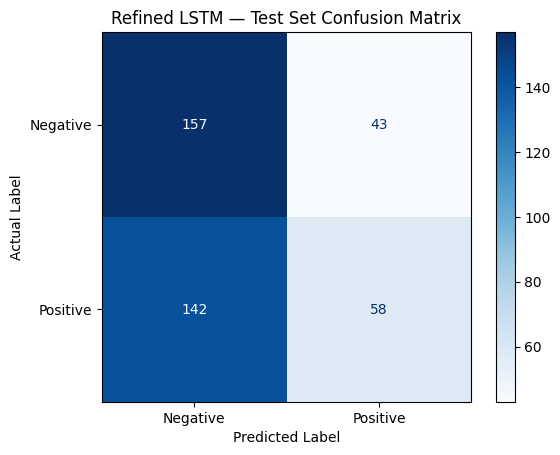

In [ ]:
# ============================================
# 7.4.18 Refined LSTM Confusion Matrix
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=refined_cm,
    display_labels=["Negative", "Positive"]
).plot(cmap="Blues", values_format="d")

plt.title("Refined LSTM — Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

#### 7.4.18 Observation — Refined LSTM Confusion Matrix

The confusion matrix shows that the refined LSTM correctly classified **157
of 200 negative reviews** and **58 of 200 positive reviews**.

The model produced **43 false positives** and **142 false negatives**. The
large number of false negatives indicates that the model frequently
classified genuinely positive reviews as negative.

This confirms the class-prediction bias observed earlier, where the model
predicted substantially more negative reviews than positive reviews despite
the balanced test set.

Therefore, the confusion matrix provides further evidence that the refined
LSTM has difficulty identifying positive sentiment and does not generalize
well to the unseen test reviews in its current configuration.

## Section 8: Pretrained Model Inference

### 8.1 Pretrained Model Strategy

The third pipeline uses an existing pretrained sentiment analysis model rather
than training a new classifier on the Movie Reviews training set.

For this assignment, the **NLTK VADER (Valence Aware Dictionary and sEntiment
Reasoner)** sentiment analyzer is selected.

Unlike the TF-IDF + Logistic Regression and LSTM pipelines, VADER does not
learn model parameters from the 1,600 training reviews. Instead, it uses its
pre-existing sentiment lexicon and rule-based scoring mechanism to estimate
the sentiment of each review.

The same untouched 400-review test set used by the previous two pipelines
will be used for evaluation. This ensures that all three approaches are
compared on exactly the same observations.

The VADER compound sentiment score will subsequently be converted into a
binary Positive/Negative prediction so that its output is directly
comparable with the two trained classification models.

#### 8.1.1 Model Selection

**Selected model:** NLTK VADER SentimentIntensityAnalyzer

VADER is selected because:

- It is an existing sentiment analysis system available through NLTK.
- It does not require training on the Movie Reviews training set.
- It produces sentiment polarity scores that can be converted into binary
  sentiment predictions.
- It provides a useful contrast with the two models trained from scratch.
- Its lightweight execution makes it suitable for evaluating the trade-off
  between model performance, computational requirements, and development
  effort.

The model will be applied only for inference on the test reviews. No model
training or parameter fitting will be performed using the Movie Reviews
dataset.

#### 8.1.2 Why VADER?

VADER provides a useful third perspective for the consultancy comparison.

The first pipeline learns statistical associations from the assignment
dataset using TF-IDF features and Logistic Regression. The second pipeline
learns distributed word representations and sequential patterns using a
PyTorch LSTM.

VADER follows a fundamentally different approach: it relies on an existing
sentiment lexicon and sentiment-scoring rules rather than learning from the
Movie Reviews training data.

This allows the experiment to investigate an important practical question:
whether an immediately available pretrained/off-the-shelf sentiment system
can provide useful performance without the cost of collecting training data
or training a model from scratch.

Its performance will be evaluated on the same 400-review test set as the
other two pipelines.

### 8.2 Pretrained Model Setup

#### 8.2.1 Import and Initialize Model

The NLTK VADER sentiment analyzer is initialized for inference.

No training is performed. The analyzer is used with its existing sentiment
lexicon and scoring configuration.

In [ ]:
# ============================================
# 8.2.1 Import and Initialize VADER
# ============================================

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon required for inference
nltk.download("vader_lexicon")

# Initialize the pretrained/off-the-shelf sentiment analyzer
vader = SentimentIntensityAnalyzer()

print("VADER sentiment analyzer initialized successfully.")
print("Model type:", type(vader).__name__)
print("Training on Movie Reviews dataset: No")
print("Inference mode: Ready")

VADER sentiment analyzer initialized successfully.
Model type: SentimentIntensityAnalyzer
Training on Movie Reviews dataset: No
Inference mode: Ready


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


#### 8.2.2 Verify Pretrained Model Configuration

Before performing inference, the VADER analyzer configuration is inspected to
confirm that the expected sentiment lexicon is available.

VADER produces four sentiment scores for each input:

- **Negative (neg):** proportion of negative sentiment
- **Neutral (neu):** proportion of neutral sentiment
- **Positive (pos):** proportion of positive sentiment
- **Compound:** normalized overall sentiment score ranging from -1 to +1

The compound score will later be used to convert VADER's output into binary
sentiment labels for comparison with the TF-IDF + Logistic Regression and
LSTM pipelines.

In [ ]:
# ============================================
# 8.2.2 Verify VADER Configuration
# ============================================

# Inspect the number of entries in the VADER sentiment lexicon
lexicon_size = len(vader.lexicon)

print("VADER configuration verified successfully.")
print("Sentiment lexicon entries:", lexicon_size)

print("\nExpected VADER output fields:")
print("- neg      : Negative sentiment score")
print("- neu      : Neutral sentiment score")
print("- pos      : Positive sentiment score")
print("- compound : Overall normalized sentiment score (-1 to +1)")

VADER configuration verified successfully.
Sentiment lexicon entries: 7502

Expected VADER output fields:
- neg      : Negative sentiment score
- neu      : Neutral sentiment score
- pos      : Positive sentiment score
- compound : Overall normalized sentiment score (-1 to +1)


### 8.3 Test Set Inference

The pretrained VADER model is now applied to the Movie Reviews test set.

Unlike the TF-IDF and LSTM pipelines, no fitting or parameter learning is
performed. VADER directly analyzes the supplied review text using its existing
sentiment lexicon and scoring rules.

Before processing the complete test set, a small sample of reviews is
inspected to understand the raw sentiment scores produced by the model.

#### 8.3.1 Inspect VADER Sentiment Scores

VADER returns four sentiment scores for each review: negative (`neg`),
neutral (`neu`), positive (`pos`), and compound (`compound`).

The compound score summarizes the overall sentiment on a scale from -1 to +1.
A positive compound score indicates more positive sentiment, while a negative
score indicates more negative sentiment.

The raw scores are inspected before defining the binary classification rule
that will be applied consistently to the complete test set.

In [ ]:
# ============================================
# 8.3.1 Inspect VADER Sentiment Scores
# ============================================

# Use ORIGINAL test reviews for VADER inference.
# This preserves the linguistic cues available to the off-the-shelf model.
sample_size = 5

print(f"Inspecting VADER scores for {sample_size} test reviews...")
print("=" * 80)

for i in range(sample_size):

    review = X_test.iloc[i]

    scores = vader.polarity_scores(review)

    print(f"\nReview {i + 1}")
    print("-" * 80)

    print("Actual label :", y_test.iloc[i])

    print("Review:")
    print(review[:500])

    print("\nVADER scores:")
    print(f"Negative  : {scores['neg']:.4f}")
    print(f"Neutral   : {scores['neu']:.4f}")
    print(f"Positive  : {scores['pos']:.4f}")
    print(f"Compound  : {scores['compound']:.4f}")

Inspecting VADER scores for 5 test reviews...

Review 1
--------------------------------------------------------------------------------
Actual label : neg
Review:
dr dolittle ( 20th century fox ) running time : 1 hour 25 minutes starring eddie murphy directed by betty thomas riding high on the success of the nutty professor ( 1996 ) , murphy returns in this abysmal comedy . 
he plays doctor john dolittle , who as a child had the ability to understand animals . 
however , after being 'exorcised' he loses this ability , and we fast forward to see dolittle in a crummy job surrounding by crummy people ( most notably dr mark weller , played by oliver platt . )

VADER scores:
Negative  : 0.1240
Neutral   : 0.6710
Positive  : 0.2050
Compound  : 0.9926

Review 2
--------------------------------------------------------------------------------
Actual label : neg
Review:
 " spawn " features good guys , bad guys , lots of fighting , bloody violence , a leather-clad machine gun chick , gooey , sel

#### 8.3.2 Convert VADER Scores to Binary Labels

VADER produces a normalized compound sentiment score ranging from -1 to +1.
To convert this continuous score into the binary sentiment labels required by
the assignment, the standard VADER compound-score threshold is used.

The classification rule is:

- Compound score >= 0.05 → Positive
- Compound score < 0.05 → Negative

This rule is applied consistently to every test review without fitting or
tuning the threshold using the Movie Reviews test set.

The resulting predictions will use the same `pos` and `neg` label format used
by the TF-IDF + Logistic Regression and LSTM pipelines, allowing direct
comparison across all three approaches.

In [ ]:
# ============================================
# 8.3.2 Convert VADER Scores to Binary Labels
# ============================================

VADER_THRESHOLD = 0.05

def vader_to_label(compound_score):
    """
    Convert a VADER compound score into a binary sentiment label.

    Standard VADER threshold:
    compound >= 0.05 -> positive
    compound < 0.05  -> negative
    """
    if compound_score >= VADER_THRESHOLD:
        return "pos"
    else:
        return "neg"


# Verify the conversion rule with representative scores
test_scores = [-0.90, -0.05, 0.00, 0.04, 0.05, 0.50, 0.90]

print("VADER binary classification rule:")
print(f"Threshold: {VADER_THRESHOLD}")

for score in test_scores:
    print(
        f"Compound score: {score:>5.2f} -> "
        f"Predicted label: {vader_to_label(score)}"
    )

VADER binary classification rule:
Threshold: 0.05
Compound score: -0.90 -> Predicted label: neg
Compound score: -0.05 -> Predicted label: neg
Compound score:  0.00 -> Predicted label: neg
Compound score:  0.04 -> Predicted label: neg
Compound score:  0.05 -> Predicted label: pos
Compound score:  0.50 -> Predicted label: pos
Compound score:  0.90 -> Predicted label: pos


#### 8.3.3 Run VADER Inference on the Complete Test Set

The VADER sentiment analyzer is now applied to all 400 reviews in the
untouched test set.

For each review, the raw VADER compound score and the corresponding binary
sentiment prediction are stored.

No training, fitting, or parameter optimization is performed during this
process. The same 400 test reviews used for the TF-IDF + Logistic Regression
and LSTM pipelines are used here to maintain a consistent evaluation basis.

In [ ]:
# ============================================
# 8.3.3 Run VADER Inference on Complete Test Set
# ============================================

vader_compound_scores = []
vader_predictions = []

for review in X_test:

    # Generate VADER sentiment scores
    scores = vader.polarity_scores(review)

    # Store compound score
    compound_score = scores["compound"]
    vader_compound_scores.append(compound_score)

    # Convert compound score to binary label
    predicted_label = vader_to_label(compound_score)
    vader_predictions.append(predicted_label)


print("VADER inference completed successfully.")

print("Number of test reviews processed:", len(X_test))
print("Number of compound scores:", len(vader_compound_scores))
print("Number of predictions:", len(vader_predictions))

print(
    "Prediction/label lengths match:",
    len(vader_predictions) == len(y_test)
)

print("\nFirst 10 VADER predictions:")
print(vader_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].tolist())

VADER inference completed successfully.
Number of test reviews processed: 400
Number of compound scores: 400
Number of predictions: 400
Prediction/label lengths match: True

First 10 VADER predictions:
['pos', 'neg', 'pos', 'pos', 'neg', 'pos', 'pos', 'neg', 'neg', 'pos']

First 10 actual labels:
['neg', 'neg', 'pos', 'neg', 'neg', 'pos', 'pos', 'neg', 'neg', 'pos']


#### 8.3.4 Verify VADER Prediction Distribution

Before calculating the final evaluation metrics, the distribution of VADER's
predicted sentiment classes is inspected.

This provides an additional diagnostic check to determine whether the
pretrained model produces a reasonably balanced set of positive and negative
predictions or shows a systematic tendency toward one class.

The actual test-set distribution is also displayed for comparison.

In [ ]:
# ============================================
# 8.3.4 Verify VADER Prediction Distribution
# ============================================

vader_prediction_series = pd.Series(
    vader_predictions,
    name="VADER Prediction"
)

print("VADER predicted class distribution:")
print(vader_prediction_series.value_counts())

print("\nVADER predicted class proportions:")
print(vader_prediction_series.value_counts(normalize=True))

print("\nActual test class distribution:")
print(y_test.value_counts())

print("\nActual test class proportions:")
print(y_test.value_counts(normalize=True))

VADER predicted class distribution:
VADER Prediction
pos    265
neg    135
Name: count, dtype: int64

VADER predicted class proportions:
VADER Prediction
pos    0.6625
neg    0.3375
Name: proportion, dtype: float64

Actual test class distribution:
label
neg    200
pos    200
Name: count, dtype: int64

Actual test class proportions:
label
neg    0.5
pos    0.5
Name: proportion, dtype: float64


### 8.4 VADER Evaluation

#### 8.4.1 Calculate VADER Evaluation Metrics

The VADER predictions are evaluated against the same 400-review test set used
by the trained models.

To ensure a fair comparison across all three NLP pipelines, the same evaluation
metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score

Precision, recall and F1-score use the positive sentiment class as the
target class, consistent with the evaluation of the other pipelines.

In [ ]:
# ============================================
# 8.4.1 Calculate VADER Evaluation Metrics
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
vader_accuracy = accuracy_score(
    y_test,
    vader_predictions
)

vader_precision = precision_score(
    y_test,
    vader_predictions,
    pos_label="pos"
)

vader_recall = recall_score(
    y_test,
    vader_predictions,
    pos_label="pos"
)

vader_f1 = f1_score(
    y_test,
    vader_predictions,
    pos_label="pos"
)

print("VADER Evaluation")
print("=" * 45)

print(f"Accuracy :  {vader_accuracy:.4f}")
print(f"Precision:  {vader_precision:.4f}")
print(f"Recall   :  {vader_recall:.4f}")
print(f"F1-score :  {vader_f1:.4f}")

VADER Evaluation
Accuracy :  0.6475
Precision:  0.6113
Recall   :  0.8100
F1-score :  0.6968


#### 8.4.2 Confusion Matrix and Classification Report

A confusion matrix and classification report are generated to examine the
types of errors made by VADER.

The confusion matrix identifies:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

The classification report provides class-level precision, recall and F1-score.
This allows the VADER model's positive and negative sentiment behavior to be
examined in greater detail before comparing it with the trained models.

In [ ]:
# ============================================
# 8.4.2 VADER Confusion Matrix & Classification Report
# ============================================

from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
vader_cm = confusion_matrix(
    y_test,
    vader_predictions,
    labels=["neg", "pos"]
)

print("VADER Confusion Matrix")
print("=" * 45)
print(vader_cm)

# Extract confusion matrix components
tn, fp, fn, tp = vader_cm.ravel()

print("\nConfusion Matrix Components:")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        vader_predictions,
        labels=["neg", "pos"],
        target_names=["Negative", "Positive"],
        digits=4
    )
)

VADER Confusion Matrix
[[ 97 103]
 [ 38 162]]

Confusion Matrix Components:
True Negatives : 97
False Positives: 103
False Negatives: 38
True Positives : 162

Classification Report:
              precision    recall  f1-score   support

    Negative     0.7185    0.4850    0.5791       200
    Positive     0.6113    0.8100    0.6968       200

    accuracy                         0.6475       400
   macro avg     0.6649    0.6475    0.6379       400
weighted avg     0.6649    0.6475    0.6379       400



#### 8.4.3 VADER Evaluation – Observation

VADER achieved an accuracy of **64.75%** and an F1-score of **69.68%** on the
400-review test set. For the positive class, the model achieved **61.13%
precision** and **81.00% recall**.

The confusion matrix shows **162 true positives** and **97 true negatives**.
However, VADER also produced **103 false positives**, compared with only
**38 false negatives**.

This indicates that VADER was substantially more likely to classify a review
as positive than negative. This is consistent with the prediction distribution:
VADER predicted **265 reviews as positive (66.25%)** and **135 as negative
(33.75%)**, while the actual test set contained **200 positive and 200
negative reviews**.

The results suggest that the pretrained sentiment analyzer can identify many
positive reviews but has difficulty distinguishing negative movie reviews in
this dataset. The likely reasons for this behavior will be examined later in
the final analysis, particularly in terms of **domain adaptation** between
the data used to develop the pretrained model and the movie-review domain used
in this assignment.

#### 8.4.4 VADER Inference Time

Unlike the TF-IDF + Logistic Regression and LSTM pipelines, VADER is not
trained on the Movie Reviews dataset. Therefore, no model training time is
reported for VADER.

To provide a useful deployment-oriented comparison, the time required to run
VADER inference across the complete 400-review test set is measured.

This timing represents inference time only and does not include model
initialization or any training/fitting process.

In [ ]:
# ============================================
# 8.4.4 Measure VADER Inference Time
# ============================================

import time

# Measure inference time across the complete test set
vader_start_time = time.time()

vader_timed_scores = []
vader_timed_predictions = []

for review in X_test:
    scores = vader.polarity_scores(review)

    compound_score = scores["compound"]
    predicted_label = vader_to_label(compound_score)

    vader_timed_scores.append(compound_score)
    vader_timed_predictions.append(predicted_label)

vader_inference_time = time.time() - vader_start_time

print("VADER inference timing completed.")
print(f"Test reviews processed: {len(X_test)}")
print(f"Inference time: {vader_inference_time:.6f} seconds")

print(
    f"Average inference time per review: "
    f"{vader_inference_time / len(X_test):.6f} seconds"
)

print(
    "Predictions identical to previous VADER run:",
    vader_timed_predictions == vader_predictions
)

VADER inference timing completed.
Test reviews processed: 400
Inference time: 6.744797 seconds
Average inference time per review: 0.016862 seconds
Predictions identical to previous VADER run: True


### 8.5 Inference Time Analysis

#### 8.5.1 Logistic Regression Inference Time

The inference time of the trained TF-IDF + Logistic Regression pipeline is
measured on the complete 400-review test set.

This measures prediction time only. It does not include model training or
TF-IDF fitting.

The timing is recorded separately from training time so that computational
cost can be compared more clearly across the three approaches.

In [ ]:
# ============================================
# 8.5.1 Measure Logistic Regression Inference Time
# ============================================

import time

logistic_start_time = time.time()

# Generate predictions using the already-fitted TF-IDF + Logistic Regression pipeline
logistic_timed_predictions = logistic_model.predict(X_test_tfidf)

logistic_inference_time = time.time() - logistic_start_time

print("Logistic Regression inference timing completed.")
print(f"Test reviews processed: {len(X_test_clean)}")
print(f"Inference time: {logistic_inference_time:.6f} seconds")

print(
    f"Average inference time per review: "
    f"{logistic_inference_time / len(X_test_clean):.6f} seconds"
)

print(
    "Predictions identical to previous Logistic Regression run:",
    np.array_equal(logistic_timed_predictions, y_pred)
)

Logistic Regression inference timing completed.
Test reviews processed: 400
Inference time: 0.005250 seconds
Average inference time per review: 0.000013 seconds


NameError: name 'y_pred' is not defined

In [ ]:
# ============================================
# Verify Timed Logistic Regression Predictions
# ============================================

print("Number of timed predictions:", len(logistic_timed_predictions))
print("Number of test labels:", len(y_test))

print(
    "Prediction/label lengths match:",
    len(logistic_timed_predictions) == len(y_test)
)

print("\nTimed prediction class distribution:")
print(pd.Series(logistic_timed_predictions).value_counts())

Number of timed predictions: 400
Number of test labels: 400
Prediction/label lengths match: True

Timed prediction class distribution:
pos    208
neg    192
Name: count, dtype: int64


#### 8.5.2 Refined LSTM Inference Time

The inference time of the final refined PyTorch LSTM is measured on the
complete 400-review test set.

Only prediction time is measured. Model training time is reported separately.

The refined LSTM uses the 400-token sequence length selected during model
refinement.

In [ ]:
# ============================================
# 8.5.2 Measure Refined LSTM Inference Time
# ============================================

import time

lstm_model_refined.eval()

lstm_start_time = time.time()

with torch.no_grad():
    lstm_logits = lstm_model_refined(
        X_test_refined_tensor.to(device)
    )

    lstm_timed_predictions = (
        (torch.sigmoid(lstm_logits) >= 0.5)
        .int()
        .cpu()
        .numpy()
        .flatten()
    )

lstm_inference_time = time.time() - lstm_start_time

print("Refined LSTM inference timing completed.")
print(f"Test reviews processed: {len(X_test_refined_tensor)}")
print(f"Inference time: {lstm_inference_time:.6f} seconds")

print(
    f"Average inference time per review: "
    f"{lstm_inference_time / len(X_test_refined_tensor):.6f} seconds"
)

print("Number of predictions:", len(lstm_timed_predictions))

print(
    "Prediction/label lengths match:",
    len(lstm_timed_predictions) == len(y_test_refined_tensor)
)

Refined LSTM inference timing completed.
Test reviews processed: 400
Inference time: 2.282037 seconds
Average inference time per review: 0.005705 seconds
Number of predictions: 400
Prediction/label lengths match: True


### 8.6 Consolidated Pipeline Performance Comparison

The three sentiment analysis pipelines are now compared using the same
400-review test set.

The comparison includes predictive performance and computational cost.
For the models trained from scratch, training time is reported separately
from test-set inference time.

VADER does not require task-specific training, so its training time is
reported as not applicable.

The comparison will be used to evaluate the trade-off between predictive
performance, computational cost, development effort, and suitability for
production deployment.

#### 8.6.1 Consolidated Results

The three sentiment analysis pipelines were evaluated on the same
400-review test set.

The comparison includes Accuracy, Precision, Recall, F1-score, training
time, and test-set inference time.

For VADER, task-specific training was not performed because it is a
pretrained sentiment analyzer used directly for inference.

In [ ]:
# ============================================
# 8.6.1 Consolidated Pipeline Results
# ============================================

results_comparison = pd.DataFrame([
    {
        "Pipeline": "TF-IDF + Logistic Regression",
        "Accuracy": 0.8550,
        "Precision": 0.8413,
        "Recall": 0.8750,
        "F1-score": 0.8578,
        "Training Time (sec)": 0.490934,
        "Inference Time (sec)": 0.005250
    },
    {
        "Pipeline": "Refined PyTorch LSTM",
        "Accuracy": 0.5375,
        "Precision": 0.5743,
        "Recall": 0.2900,
        "F1-score": 0.3854,
        "Training Time (sec)": 550.890200,
        "Inference Time (sec)": 2.282037
    },
    {
        "Pipeline": "VADER",
        "Accuracy": 0.6475,
        "Precision": 0.6113,
        "Recall": 0.8100,
        "F1-score": 0.6968,
        "Training Time (sec)": np.nan,
        "Inference Time (sec)": 6.744797
    }
])

print("Consolidated Pipeline Performance")
print("=" * 80)

display(
    results_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "Training Time (sec)": "{:.4f}",
        "Inference Time (sec)": "{:.6f}"
    })
)

Consolidated Pipeline Performance


,Pipeline,Accuracy,Precision,Recall,F1-score,Training Time (sec),Inference Time (sec)
0,TF-IDF + Logistic Regression,0.8550,0.8413,0.8750,0.8578,0.4909,0.005250
1,Refined PyTorch LSTM,0.5375,0.5743,0.2900,0.3854,550.8902,2.282037
2,VADER,0.6475,0.6113,0.8100,0.6968,nan,6.744797


#### 8.6.2 Performance Comparison

The results show clear differences between the three sentiment analysis
approaches when evaluated on the same 400-review test set.

**TF-IDF + Logistic Regression** achieved the strongest overall predictive
performance, with an accuracy of **85.50%** and an F1-score of **85.78%**.
It also achieved the highest precision (**84.13%**) and recall (**87.50%**)
among the three pipelines.

The model was also highly computationally efficient. Training required
approximately **0.491 seconds**, while inference on the 400-review test set
required only **0.005250 seconds**.

The **Refined PyTorch LSTM** achieved an accuracy of **53.75%** and an
F1-score of **38.54%**. Its positive-class recall was **29.00%**, indicating
difficulty identifying positive reviews in the test set. The model required
approximately **550.89 seconds** for training and **2.282037 seconds** for
test-set inference. These results show that the LSTM configuration used in
this experiment required substantially greater computational effort while
achieving lower predictive performance than the traditional ML approach.

**VADER**, which was used as a pretrained sentiment analyzer without any
task-specific training, achieved **64.75% accuracy** and an **F1-score of
69.68%**. It achieved relatively high positive-class recall (**81.00%**),
although its precision was lower (**61.13%**). The measured inference time
for the 400-review test set was **6.744797 seconds**. Training time is
reported as **N/A — Pretrained** because VADER was not trained on the
Movie Reviews dataset.

Overall, the experimental results indicate that **TF-IDF + Logistic
Regression provided the strongest combination of predictive performance
and computational efficiency** for this dataset and experimental setup.

#### 8.6.3 Key Findings

The comparison produces the following key findings:

1. **Best predictive performance:**  
   TF-IDF + Logistic Regression achieved the highest accuracy (**85.50%**)
   and highest F1-score (**85.78%**) among the three pipelines.

2. **Best training efficiency among trainable models:**  
   Logistic Regression required approximately **0.491 seconds** to train,
   compared with approximately **550.89 seconds** for the refined LSTM.

3. **Fastest measured inference:**  
   Logistic Regression required approximately **0.005250 seconds** to
   process the 400-review test set, making it the fastest measured pipeline
   in this experiment.

4. **Strong positive-class recall from VADER:**  
   VADER achieved **81.00% positive-class recall**, but its precision was
   lower at **61.13%**, resulting in an F1-score of **69.68%**.

5. **Weakest current experimental performance:**  
   The refined LSTM achieved **53.75% accuracy** and an **F1-score of
   38.54%**. Its positive-class recall was only **29.00%**, while requiring
   substantially greater training time than Logistic Regression.

6. **No task-specific training for VADER:**  
   VADER was used directly as a pretrained sentiment analyzer and therefore
   did not require training on the Movie Reviews dataset. Its training time
   is therefore reported as **N/A — Pretrained**.

7. **Overall trade-off:**  
   Based on the measured results, TF-IDF + Logistic Regression provides the
   most favorable balance of predictive quality, training cost, and
   inference efficiency for the current Movie Reviews sentiment-analysis
   experiment.

## Section 9: Final Analysis & Business Recommendation

The objective of the final analysis is to compare the three sentiment
analysis pipelines from both a predictive-performance and business
perspective.

The comparison considers evaluation metrics, training requirements,
inference cost, computational resources, and practical suitability for
production deployment.

### 9.1 Which Pipeline Performed Best?

Based on the experimental results, **TF-IDF + Logistic Regression performed
best overall** on the NLTK Movie Reviews test set.

It achieved the highest performance across all four reported evaluation
metrics:

- **Accuracy:** 85.50%
- **Precision:** 84.13%
- **Recall:** 87.50%
- **F1-score:** 85.78%

The model also demonstrated very low computational cost. Training required
only approximately **0.491 seconds**, and inference on the 400-review test
set required approximately **0.005250 seconds**.

The refined LSTM achieved substantially lower performance, with an accuracy
of 53.75% and an F1-score of 38.54%, while requiring approximately
550.89 seconds of training time. Its positive-class recall of 29.00% also
indicates difficulty identifying positive reviews.

VADER achieved intermediate predictive performance, with 64.75% accuracy
and an F1-score of 69.68%. It required no task-specific training because
it is a pretrained sentiment analyzer, but its measured inference time was
6.744797 seconds for the 400-review test set.

Therefore, within this experiment, **TF-IDF + Logistic Regression provides
the strongest combination of predictive performance and computational
efficiency**.

### 9.2 Why Did the Pretrained Model Perform Differently?

VADER produced an intermediate level of performance compared with the two
models trained from scratch. It achieved **64.75% accuracy** and an
**F1-score of 69.68%**, which was higher than the refined LSTM's F1-score
of 38.54% but lower than the TF-IDF + Logistic Regression F1-score of
85.78%.

The key factor is **domain adaptation**. VADER is a pretrained,
rule-and-lexicon-based sentiment analyzer that can be applied directly to
new text without being trained on the NLTK Movie Reviews dataset. In this
experiment, the model therefore had no opportunity to learn sentiment
patterns specifically from the movie-review training data.

Movie reviews contain domain-specific language, including descriptions of
acting, directing, cinematography, plots, characters, genres, and
film-specific expressions. Some words and phrases may also express
sentiment differently depending on their context. A general-purpose
sentiment lexicon may therefore interpret some movie-review language
differently from a model trained directly on the target dataset.

The observed confusion matrix provides evidence of this behavior. VADER
correctly identified **162 of 200 positive reviews**, resulting in a
positive-class recall of **81.00%**. However, it also incorrectly classified
**103 negative reviews as positive**, producing a relatively low
positive-class precision of **61.13%**.

This suggests that VADER was effective at detecting many reviews containing
positive sentiment signals, but it was less effective at distinguishing
positive sentiment from the more complex contextual language present in
movie reviews.

In contrast, TF-IDF + Logistic Regression learned statistical word and
phrase patterns directly from the training portion of the same Movie
Reviews dataset. This form of task-specific adaptation likely contributed
to its substantially stronger performance.

Therefore, the VADER results demonstrate an important trade-off of
pretrained models: they can provide immediate sentiment-analysis
capability without task-specific training, but their performance may be
limited when the target domain contains language patterns that differ from
those represented by the pretrained sentiment knowledge.

### 9.3 Why These Evaluation Metrics?

Four evaluation metrics were considered for comparing the sentiment
classification pipelines: **Accuracy, Precision, Recall, and F1-score**.

**Accuracy** measures the overall proportion of test reviews that were
classified correctly. It provides a straightforward summary of overall
classification performance. The test set contains an equal number of
positive and negative reviews (200 each), so accuracy is useful as an
overall measure in this experiment.

**Precision** measures how many reviews predicted as positive were actually
positive. This is important when false-positive predictions have a business
cost. For example, incorrectly identifying a negative customer opinion as
positive could lead to an overly optimistic interpretation of customer
sentiment.

**Recall** measures how many of the actual positive reviews were correctly
identified. This is useful when the business wants to minimize missed
positive sentiment and ensure that positive customer opinions are captured.

**F1-score** is the harmonic mean of Precision and Recall. It provides a
single metric that balances the two and is particularly useful when a model
may have a trade-off between false positives and false negatives.

Using all four metrics provides a more complete evaluation than relying on
accuracy alone. This is demonstrated by the experimental results. For
example, VADER achieved **64.75% accuracy** and **81.00% positive-class
recall**, but its positive-class precision was only **61.13%** because it
produced **103 false-positive predictions**. Similarly, the refined LSTM
achieved **53.75% accuracy**, but its positive-class recall was only
**29.00%**.

Therefore, Accuracy was used to assess overall correctness, while
Precision, Recall, and F1-score were used to understand the types of
classification errors and the balance between correctly identifying
positive sentiment and avoiding incorrect positive predictions.

### 9.4 Production Recommendation

Based on the experimental results, the recommended production approach for
the current movie-review sentiment analysis use case is **TF-IDF +
Logistic Regression**.

The recommendation is based on the combination of predictive performance,
computational efficiency, training requirements, and practical deployment
considerations.

**1. Predictive performance**

TF-IDF + Logistic Regression achieved the strongest results on the common
400-review test set:

- Accuracy: **85.50%**
- Precision: **84.13%**
- Recall: **87.50%**
- F1-score: **85.78%**

It outperformed both VADER and the refined LSTM across all four reported
evaluation metrics.

**2. Computational cost**

The Logistic Regression pipeline required only approximately **0.491
seconds** to train and **0.005250 seconds** to process the 400-review test
set. In comparison, the refined LSTM required approximately **550.89
seconds** for training and **2.282037 seconds** for test-set inference.

The experiment was conducted on a CPU-only environment, so these timings
represent the measured performance of the implemented pipelines in the
current experimental environment.

**3. Training data and development requirements**

The Logistic Regression model was trained directly on the Movie Reviews
training data, allowing it to learn statistical patterns specific to the
target sentiment-analysis task. The approach is also comparatively simple
to develop, train, evaluate, and maintain.

The LSTM required substantially greater computational effort and achieved
lower performance under the configuration used in this experiment. This
makes it difficult to justify its additional complexity for the current
use case based on the observed results alone.

VADER required no task-specific training and therefore provides a useful
rapid-deployment baseline. However, its lower accuracy and F1-score indicate
that it would not be the preferred option when predictive performance is
the primary requirement.

**4. Production trade-off**

For a consultancy firm seeking a practical sentiment-analysis solution,
TF-IDF + Logistic Regression provides the most favorable balance of:

- High predictive performance
- Strong Precision, Recall, and F1-score
- Very low training cost
- Very low measured inference cost
- Straightforward implementation
- Task-specific learning from available labeled data
- Lower operational complexity than the LSTM approach

Therefore, **TF-IDF + Logistic Regression should be selected for the
current production deployment**, subject to further validation on
real-world and continuously collected movie-review data.

A sensible production workflow would be to deploy the Logistic Regression
pipeline initially, monitor its performance on new out-of-sample data, and
periodically retrain it as the available labeled data grows or the language
patterns in the target domain change.

The LSTM should not be selected for production based on this experiment,
because its substantially higher computational cost did not translate into
better predictive performance. VADER remains a useful lightweight
pretrained baseline when immediate deployment without labeled training data
is required, but its current predictive performance is below that of the
task-specific Logistic Regression model.

### 9.5 Final Executive Summary

This project compared three different paradigms for sentiment analysis on
the NLTK Movie Reviews dataset: **Traditional Machine Learning using TF-IDF
+ Logistic Regression, Deep Learning using a PyTorch LSTM, and a pretrained
VADER sentiment analyzer**.

The results demonstrate a clear trade-off between model complexity,
predictive performance, and computational requirements.

**TF-IDF + Logistic Regression was the strongest overall performer**, with
**85.50% accuracy** and an **85.78% F1-score**. It also required only
approximately **0.491 seconds for training** and **0.005250 seconds for
inference on the 400-review test set**.

The **Refined PyTorch LSTM** did not outperform the traditional approach in
this experiment. It achieved **53.75% accuracy** and **38.54% F1-score**
while requiring approximately **550.89 seconds of training**. This
demonstrates that a more complex deep learning architecture does not
automatically provide better results, particularly when the available
training data and experimental configuration are limited.

**VADER** provided a useful pretrained alternative without task-specific
training. It achieved **64.75% accuracy** and **69.68% F1-score**, with
strong positive-class recall of **81.00%**. However, its performance was
below the task-specific Logistic Regression model, illustrating the
potential limitations of applying a general-purpose sentiment analyzer to
a specific domain without additional adaptation.

### Final Recommendation

For the current movie-review sentiment analysis use case, the consultancy
firm should **deploy TF-IDF + Logistic Regression** as the preferred
solution.

It provides the best observed predictive performance while also offering
very low training and inference costs and relatively low implementation
complexity.

The solution should subsequently be monitored using new out-of-sample
reviews and retrained when sufficient new labeled data becomes available.
This would allow the system to adapt to changing language patterns while
maintaining the efficiency of the selected production approach.

### Overall Business Insight

**The experiment demonstrates that the most sophisticated architecture is
not necessarily the best production choice. The best solution is the one
that provides the strongest required business performance at an appropriate
level of computational and operational cost.**